Importem llibreries y gràfica

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuració estètica
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Importem DF

In [3]:
RRHH = pd.read_pickle(r"C:\Users\PC\Desktop\ProjecteData\Equip_15\Data\RRHH_150925_clean.pkl")

In [4]:
RRHH = pd.read_csv(r"C:\Users\PC\Desktop\ProjecteData\Equip_15\Data\RRHH_150925_clean.csv")

In [5]:
RRHH.dtypes

ID                           int64
Reason_absence               int64
Month_absence               object
Day_week                    object
Seasons                     object
Transportation_expense       int64
Distance_Residence_Work      int64
Service_time                 int64
Age                          int64
Work_load_Average_day      float64
Hit_target                   int64
Disciplinary_failure         int64
Education                   object
Son                          int64
Social_drinker               int64
Social_smoker                int64
Pet                          int64
Weight                       int64
Height                       int64
Body_mass_index              int64
Absenteeism_hours            int64
Month_absence_order          int64
Day_week_order               int64
dtype: object

In [6]:
# Convertir la columna 'ID' a INT64
RRHH['ID'] = pd.to_numeric(RRHH['ID'], errors='coerce').astype('Int64')

# Si la columna es de tipo category, conviértela primero a string
if RRHH['Reason_absence'].dtype.name == 'category':
    RRHH['Reason_absence'] = RRHH['Reason_absence'].astype(str)

# Ahora convierte a numérico y luego a INT64
RRHH['Reason_absence'] = pd.to_numeric(RRHH['Reason_absence'], errors='coerce').astype('Int64')

In [7]:
RRHH.dtypes

ID                           Int64
Reason_absence               Int64
Month_absence               object
Day_week                    object
Seasons                     object
Transportation_expense       int64
Distance_Residence_Work      int64
Service_time                 int64
Age                          int64
Work_load_Average_day      float64
Hit_target                   int64
Disciplinary_failure         int64
Education                   object
Son                          int64
Social_drinker               int64
Social_smoker                int64
Pet                          int64
Weight                       int64
Height                       int64
Body_mass_index              int64
Absenteeism_hours            int64
Month_absence_order          int64
Day_week_order               int64
dtype: object

In [8]:
# Change from numeric to categorical
RRHH["Reason_absence"] = RRHH["Reason_absence"].astype("category")

# Change from object to numeric
for col in ["Son", "Pet"]:
    RRHH[col] = RRHH[col].astype("int")


RRHH["Hit_target"] = (
    RRHH["Hit_target"].astype(float)
)

RRHH.dtypes


ID                            Int64
Reason_absence             category
Month_absence                object
Day_week                     object
Seasons                      object
Transportation_expense        int64
Distance_Residence_Work       int64
Service_time                  int64
Age                           int64
Work_load_Average_day       float64
Hit_target                  float64
Disciplinary_failure          int64
Education                    object
Son                           int64
Social_drinker                int64
Social_smoker                 int64
Pet                           int64
Weight                        int64
Height                        int64
Body_mass_index               int64
Absenteeism_hours             int64
Month_absence_order           int64
Day_week_order                int64
dtype: object

In [9]:
RRHH.dtypes

ID                            Int64
Reason_absence             category
Month_absence                object
Day_week                     object
Seasons                      object
Transportation_expense        int64
Distance_Residence_Work       int64
Service_time                  int64
Age                           int64
Work_load_Average_day       float64
Hit_target                  float64
Disciplinary_failure          int64
Education                    object
Son                           int64
Social_drinker                int64
Social_smoker                 int64
Pet                           int64
Weight                        int64
Height                        int64
Body_mass_index               int64
Absenteeism_hours             int64
Month_absence_order           int64
Day_week_order                int64
dtype: object

In [10]:
# Especificar meses
month_map = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

RRHH["Month_absence"] = RRHH["Month_absence"].replace(month_map)

# Especificar días de la semana
day_map = {
    2: "Lunes", 3: "Martes", 4: "Miercoles", 5: "Jueves", 6: "Viernes"
}
RRHH["Day_week"] = RRHH["Day_week"].replace(day_map)

# Especificar estaciones (cambiando invierno por verano y primavera por otoño, etc.)
spanish_season_map = {
    1: "Invierno", 2: "Otono", 3: "Verano", 4: "Primavera"
}
RRHH["Seasons"] = RRHH["Seasons"].replace(spanish_season_map)

In [11]:
# Diccionari de motius
reason_absence_dict = {
    0: "Sin especificar / Otros",
    1: "Enfermedades infecciosas y parasitarias",
    2: "Neoplasias (tumores)",
    3: "Enfermedades de la sangre y órganos hematopoyéticos",
    4: "Enfermedades endocrinas, nutricionales y metabólicas",
    5: "Trastornos mentales y del comportamiento",
    6: "Enfermedades del sistema nervioso",
    7: "Enfermedades del ojo y sus anexos",
    8: "Enfermedades del oído y la apófisis mastoides",
    9: "Enfermedades del sistema circulatorio",
    10: "Enfermedades del sistema respiratorio",
    11: "Enfermedades del sistema digestivo",
    12: "Enfermedades de la piel y tejido subcutáneo",
    13: "Enfermedades del sistema musculoesquelético y tejido conectivo",
    14: "Enfermedades del sistema genitourinario",
    15: "Embarazo, parto y puerperio",
    16: "Condiciones originadas en el período perinatal",
    17: "Malformaciones congénitas y anomalías cromosómicas",
    18: "Síntomas y signos no clasificados",
    19: "Lesiones, envenenamientos y consecuencias de otras causas externas",
    20: "Causas externas de morbilidad y mortalidad",
    21: "Factores que influyen en el estado de salud",
    22: "Paciente en seguimiento",
    23: "Consulta médica",
    24: "Donación de sangre",
    25: "Examen de laboratorio",
    26: "Ausencia injustificada",
    27: "Fisioterapia",
    28: "Consulta dental"
}
# Diccionari simplificat per a agrupacions més generals
reason_group_dict = {
    "Enfermedades físicas": [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14],
    "Salud mental": [5],
    "Salud reproductiva": [15, 16, 17],
    "Condiciones diversas": [18, 19, 20, 21],
    "Procedimientos médicos": [22, 24, 25, 27, 28],
    "Consulta médica": [23],
    "Ausencias no justificadas": [26],
    "Otros": [0]
}

Total d'hores d'absentisme en un any

In [12]:
# Total d'hores d'absentisme en un any
total_hores_absentisme = RRHH['Absenteeism_hours'].sum()
print(f"Total d'hores d'absentisme anual: {total_hores_absentisme} hores")

# Mitjana d'hores d'absentisme per empleat
mitjana_absentisme_empleat = RRHH.groupby('ID')['Absenteeism_hours'].sum().mean()
print(f"Mitjana d'hores d'absentisme per empleat: {mitjana_absentisme_empleat:.2f} hores")

# Taxa d'absentisme (assumint 8 hores de treball per dia i 230 dies laborables anuals)
hores_treball_anuals = 36 * 8 * 230  # 36 empleats × 8 hores × 230 dies
taxa_absentisme = (total_hores_absentisme / hores_treball_anuals) * 100
print(f"Taxa d'absentisme: {taxa_absentisme:.2f}%")

Total d'hores d'absentisme anual: 5043 hores
Mitjana d'hores d'absentisme per empleat: 140.08 hores
Taxa d'absentisme: 7.61%


Interpretació:

Una taxa d'absentisme superior al 3-4% es considera generalment alta i indica problemes significatius.

Si la taxa és inferior al 2%, es pot considerar acceptable, però cal monitorar-la.

Mitjana d'hores d'absentisme per empleat per any

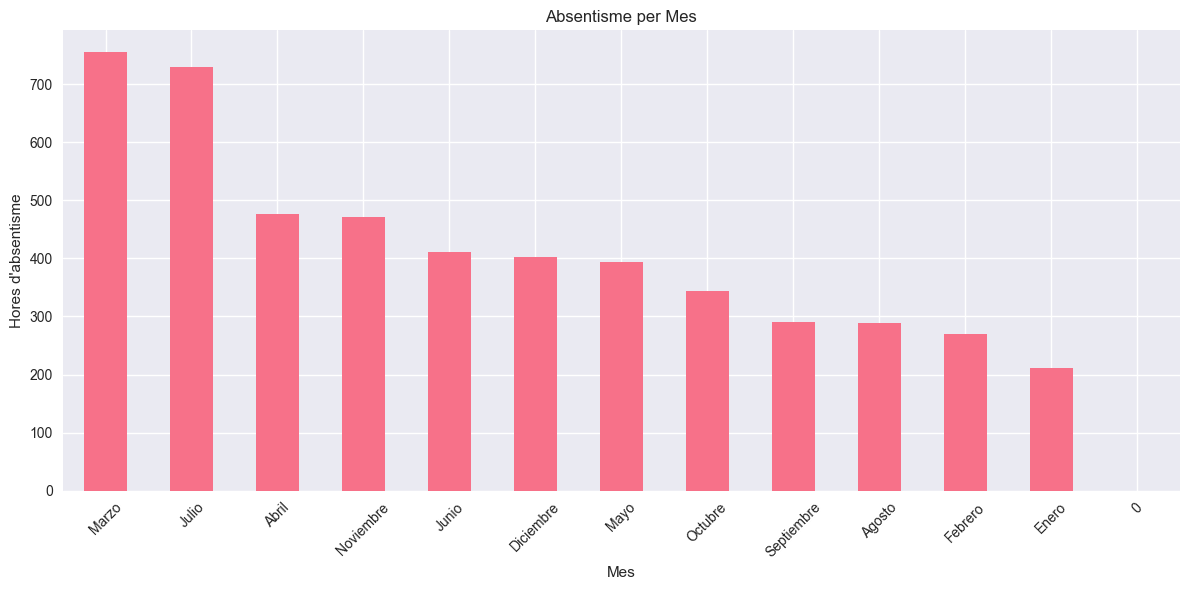

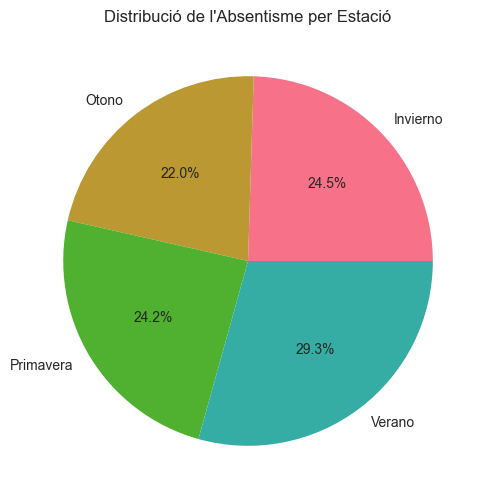

In [13]:
# Absentisme per mes
absentisme_mensual = RRHH.groupby('Month_absence')['Absenteeism_hours'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
absentisme_mensual.plot(kind='bar')
plt.title('Absentisme per Mes')
plt.xlabel('Mes')
plt.ylabel('Hores d\'absentisme')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Absentisme per estació
absentisme_estacional = RRHH.groupby('Seasons')['Absenteeism_hours'].sum()

plt.figure(figsize=(8, 6))
absentisme_estacional.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribució de l\'Absentisme per Estació')
plt.ylabel('')
plt.show()

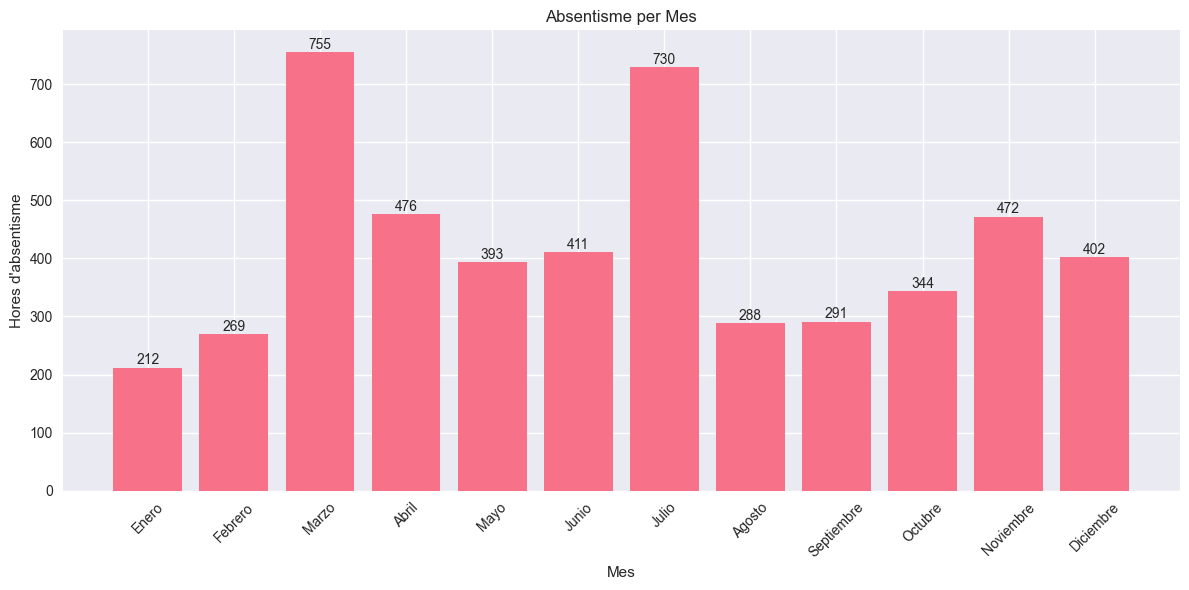

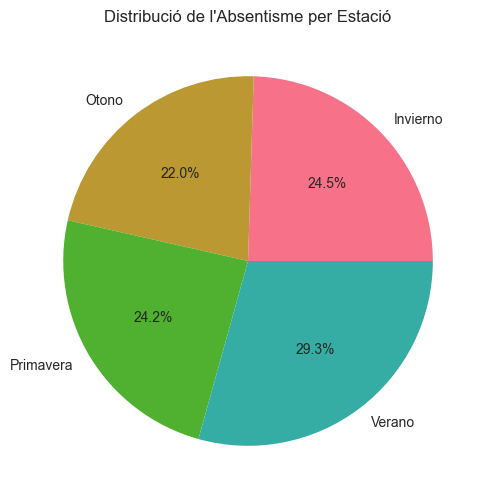

In [14]:
# Definir l'ordre cronològic dels mesos
mesos_ordenats = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", 
                  "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

# Absentisme per mes - agrupar i reindexar segons l'ordre cronològic
absentisme_mensual = RRHH.groupby('Month_absence')['Absenteeism_hours'].sum()
absentisme_mensual = absentisme_mensual.reindex(mesos_ordenats)

# Filtrar per eliminar mesos amb 0 hores (si n'hi ha)
absentisme_mensual = absentisme_mensual[absentisme_mensual > 0]

plt.figure(figsize=(12, 6))
bars = plt.bar(absentisme_mensual.index, absentisme_mensual.values)
plt.title('Absentisme per Mes')
plt.xlabel('Mes')
plt.ylabel('Hores d\'absentisme')
plt.xticks(rotation=45)

# Afegir el valor numèric a sobre de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Absentisme per estació
absentisme_estacional = RRHH.groupby('Seasons')['Absenteeism_hours'].sum()

plt.figure(figsize=(8, 6))
plt.pie(absentisme_estacional.values, labels=absentisme_estacional.index, autopct='%1.1f%%')
plt.title('Distribució de l\'Absentisme per Estació')
plt.show()

<Figure size 1400x700 with 0 Axes>

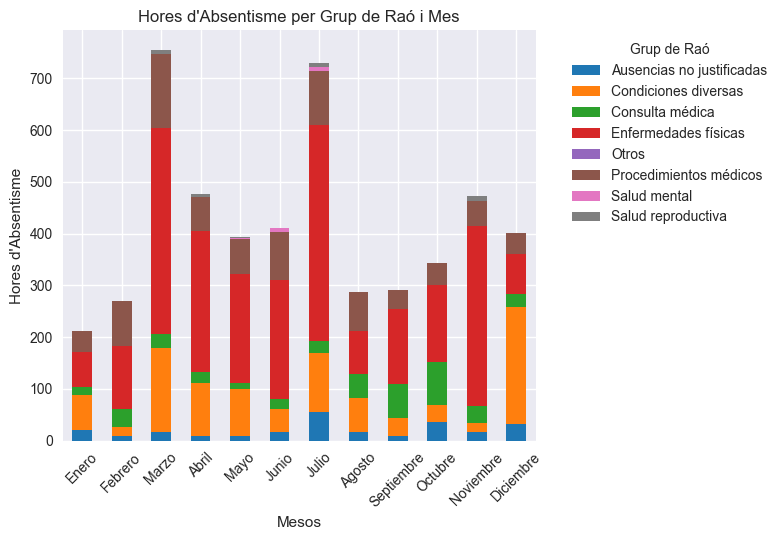

<Figure size 1400x700 with 0 Axes>

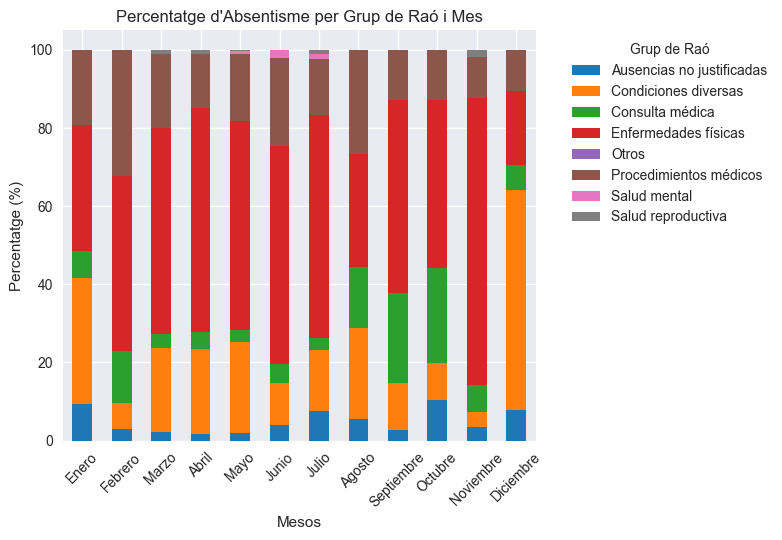

Estadístiques per grups de raó d'absentisme:
                            sum   mean  count
Reason_group                                 
Ausencias no justificadas   240   7.27     33
Condiciones diversas        981  14.64     67
Consulta médica             408   2.87    142
Enfermedades físicas       2513  13.51    186
Otros                         0   0.00     43
Procedimientos médicos      852   3.77    226
Salud mental                 19   6.33      3
Salud reproductiva           30   5.00      6


In [15]:
# Crear un diccionari invers per a mapar cada raó al seu grup
reason_to_group = {}
for group, reasons in reason_group_dict.items():
    for reason in reasons:
        reason_to_group[reason] = group

# Aplicar el mapatge de raons a grups al DataFrame
RRHH['Reason_group'] = RRHH['Reason_absence'].map(reason_to_group)

# Agrupament per grup de raó i mes
reason_by_month = RRHH.groupby(['Month_absence', 'Reason_group'])['Absenteeism_hours'].sum().reset_index()

# Pivotar per a visualització
pivot_reason = reason_by_month.pivot(index='Month_absence', columns='Reason_group', values='Absenteeism_hours').fillna(0)

# Ordenar els mesos cronològicament
mesos_ordenats = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", 
                  "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
pivot_reason = pivot_reason.reindex(mesos_ordenats)

# Nova paleta de colors amb 8 colors ben diferenciats
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

# Gràfic de barres apilades
plt.figure(figsize=(14, 7))
pivot_reason.plot(kind='bar', stacked=True, color=colors)
plt.title('Hores d\'Absentisme per Grup de Raó i Mes')
plt.xlabel('Mesos')
plt.ylabel('Hores d\'Absentisme')
plt.legend(title='Grup de Raó', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# També podem calcular el percentatge per cada grup per mes
pivot_percent = pivot_reason.div(pivot_reason.sum(axis=1), axis=0) * 100

# Gràfic de percentatges
plt.figure(figsize=(14, 7))
pivot_percent.plot(kind='bar', stacked=True, color=colors)
plt.title('Percentatge d\'Absentisme per Grup de Raó i Mes')
plt.xlabel('Mesos')
plt.ylabel('Percentatge (%)')
plt.legend(title='Grup de Raó', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Estadístiques resum per grups de raó
summary_by_reason_group = RRHH.groupby('Reason_group')['Absenteeism_hours'].agg(['sum', 'mean', 'count']).round(2)
print("Estadístiques per grups de raó d'absentisme:")
print(summary_by_reason_group)

Taxa d'absentisme

Anàlisi per Motiu d'Absència. Top 10 Motius d'Absentisme per Hores

C:\Users\PC\AppData\Local\Temp\ipykernel_20872\2689430788.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  absentisme_motiu = RRHH.groupby('Reason_absence')['Absenteeism_hours'].sum().sort_values(ascending=False)


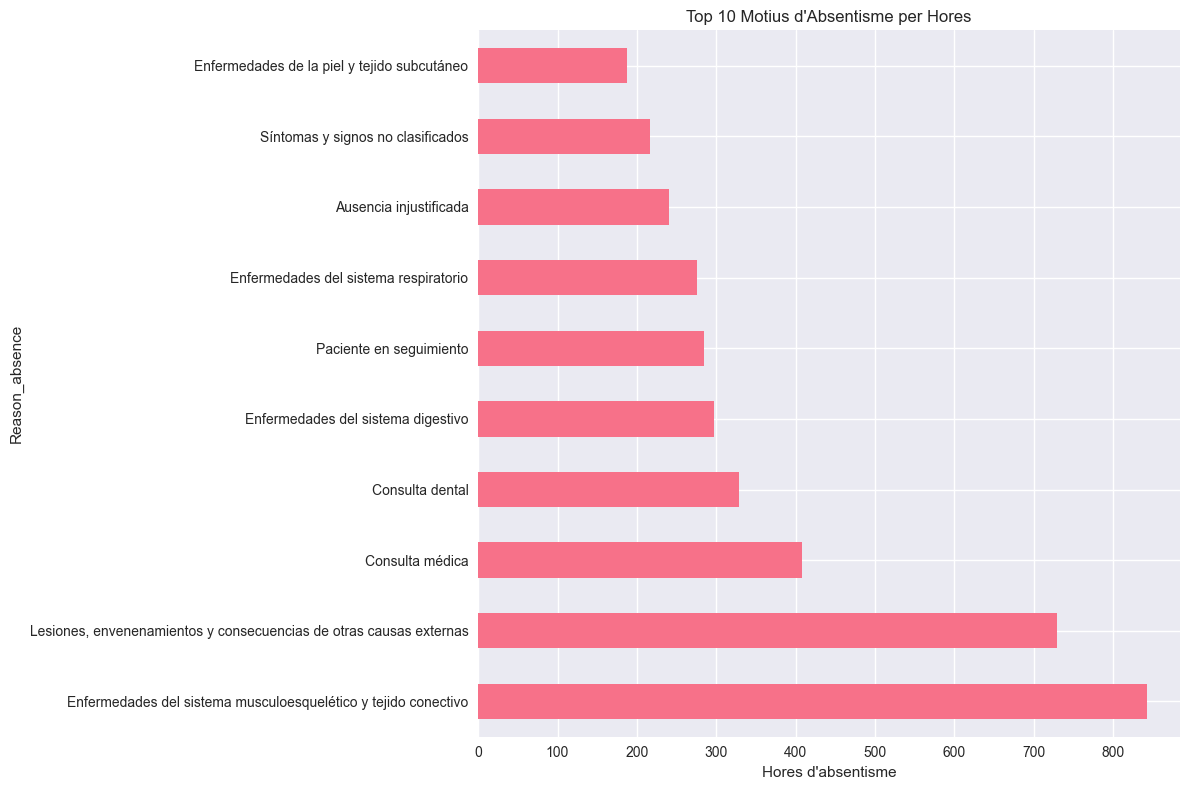

In [16]:


# Absentisme per motiu
absentisme_motiu = RRHH.groupby('Reason_absence')['Absenteeism_hours'].sum().sort_values(ascending=False)

# Convertir codis a descripcions
absentisme_motiu.index = absentisme_motiu.index.map(lambda x: reason_absence_dict.get(x, f"Motiu {x}"))

plt.figure(figsize=(12, 8))
absentisme_motiu.head(10).plot(kind='barh')
plt.title('Top 10 Motius d\'Absentisme per Hores')
plt.xlabel('Hores d\'absentisme')
plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_20872\954512833.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  absentisme_motiu = RRHH.groupby('Reason_absence')['Absenteeism_hours'].sum().sort_values(ascending=False)


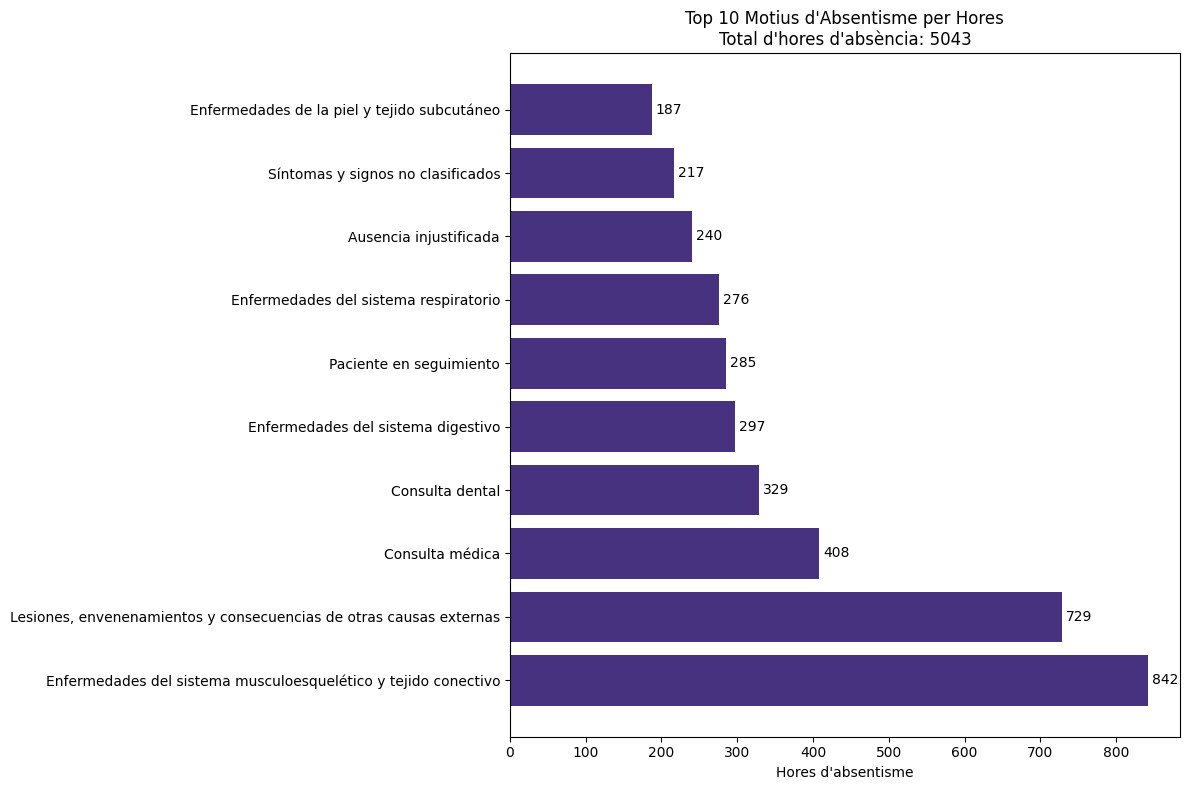

In [33]:
# Absentisme per motiu
absentisme_motiu = RRHH.groupby('Reason_absence')['Absenteeism_hours'].sum().sort_values(ascending=False)

# Convertir codis a descripcions
absentisme_motiu.index = absentisme_motiu.index.map(lambda x: reason_absence_dict.get(x, f"Motiu {x}"))

# Calcular el total d'hores d'absència
total_hores = absentisme_motiu.sum()

plt.figure(figsize=(12, 8))
bars = plt.barh(absentisme_motiu.head(10).index, absentisme_motiu.head(10).values)
plt.title(f'Top 10 Motius d\'Absentisme per Hores\nTotal d\'hores d\'absència: {total_hores}')
plt.xlabel('Hores d\'absentisme')

# Afegir els valors a les barres
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', ha='left', va='center')

plt.tight_layout()
plt.show()

Interpretació:

Les raons més comunes poden ser malaltia (codi 0), visites mèdiques (codi 1), o motius familiars (codi 3).

Si certes raons són predominants en mesos específics, es poden dissenyar intervencions dirigides. Per exemple, si la malaltia és alta en hivern, implementar programes de vacunació o promoure l'higiene.

Anàlisi per Perfil de l'Empleat

Correlació entre Age i absentisme: 0.066


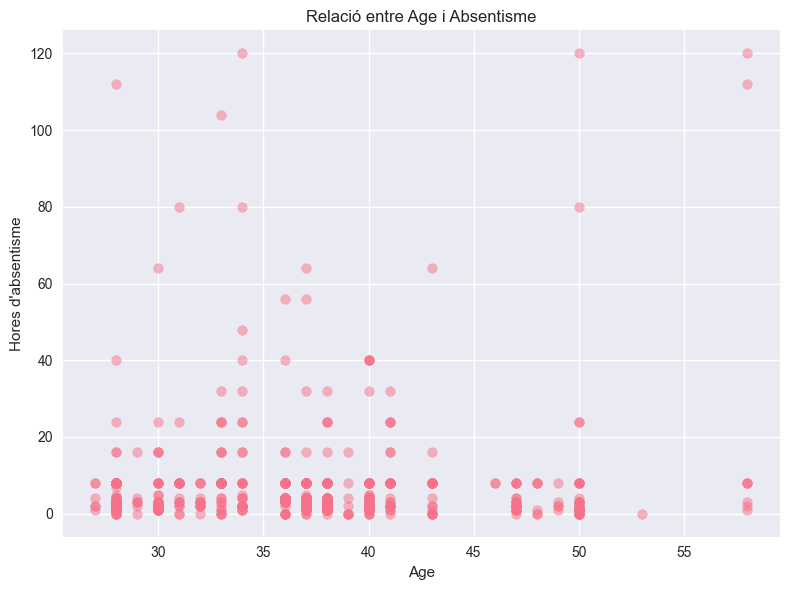

Correlació entre Son i absentisme: 0.102


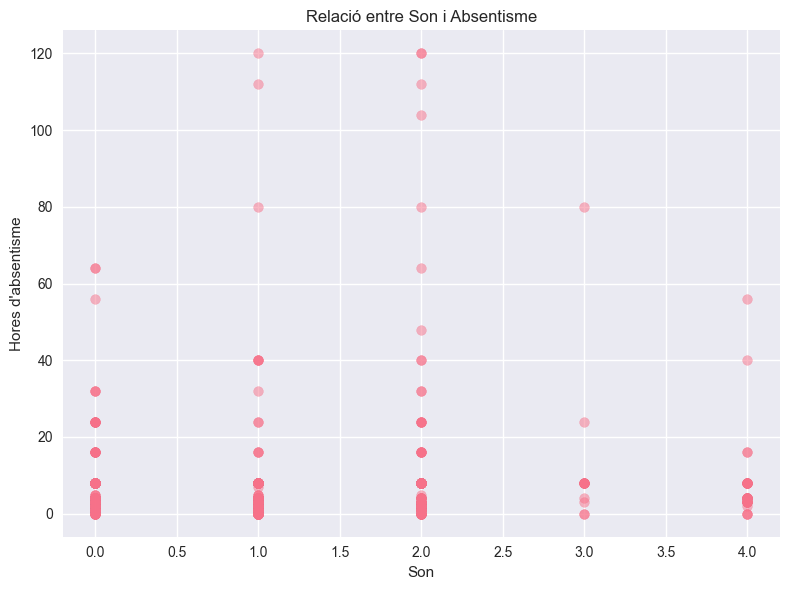

Correlació entre Pet i absentisme: -0.036


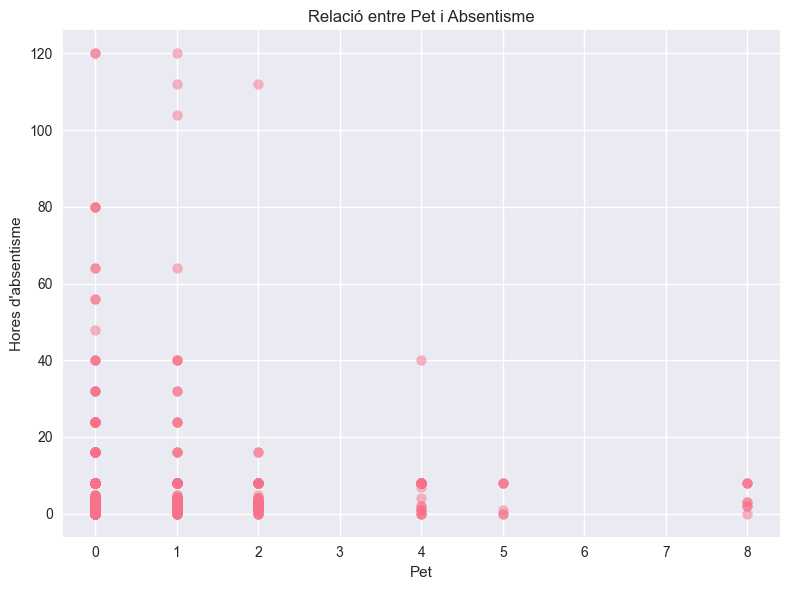

Correlació entre Social_drinker i absentisme: 0.068


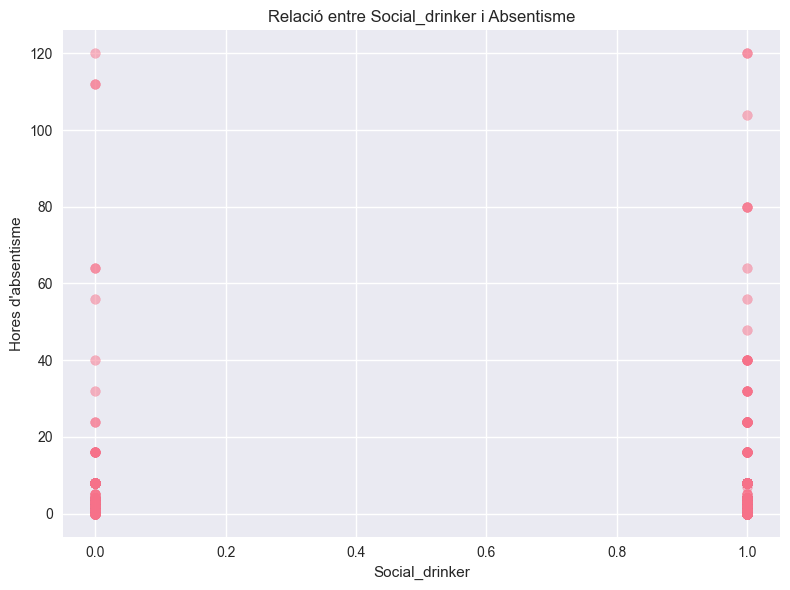

Correlació entre Social_smoker i absentisme: -0.014


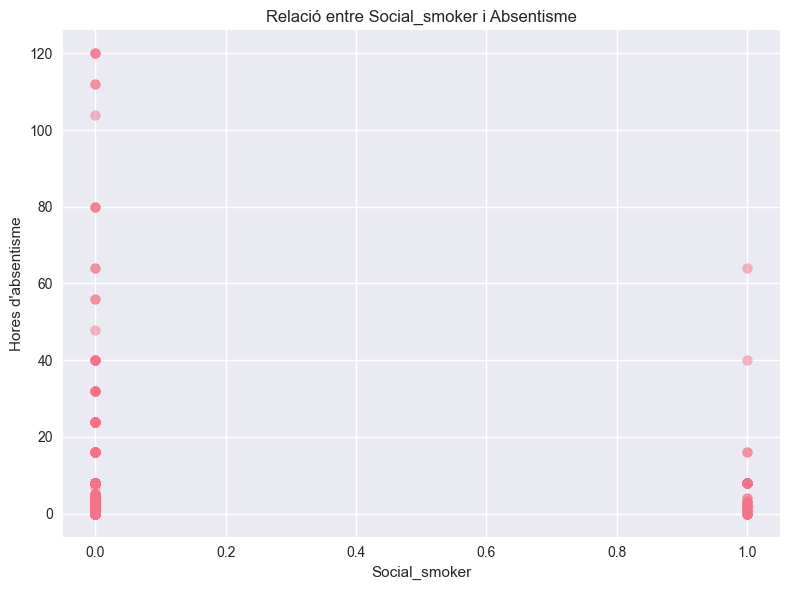

In [17]:
# Relació entre variables sociodemogràfiques i absentisme
variables_socio = ['Age', 'Son', 'Pet', 'Social_drinker', 'Social_smoker']

for var in variables_socio:
    if RRHH[var].dtype == 'object':  # Variables categòriques
        grouped = RRHH.groupby(var)['Absenteeism_hours'].mean()
        print(f"\nAbsentisme mitjà per {var}:")
        print(grouped)
        
        plt.figure(figsize=(8, 6))
        grouped.plot(kind='bar')
        plt.title(f'Absentisme mitjà per {var}')
        plt.ylabel('Hores mitjanes d\'absentisme')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:  # Variables numèriques
        correlation = RRHH[var].corr(RRHH['Absenteeism_hours'])
        print(f"Correlació entre {var} i absentisme: {correlation:.3f}")
        
        plt.figure(figsize=(8, 6))
        plt.scatter(RRHH[var], RRHH['Absenteeism_hours'], alpha=0.5)
        plt.title(f'Relació entre {var} i Absentisme')
        plt.xlabel(var)
        plt.ylabel('Hores d\'absentisme')
        plt.tight_layout()
        plt.show()

Anàlisi de Factors Laborals

In [18]:
# Factors laborals
factors_laborals = ['Distance_Residence_Work', 'Work_load_Average_day', 'Service_time', 'Disciplinary_failure']

for factor in factors_laborals:
    if RRHH[factor].dtype == 'object':  # Variables categòriques
        grouped = RRHH.groupby(factor)['Absenteeism_hours'].mean()
        print(f"\nAbsentisme mitjà per {factor}:")
        print(grouped)
    else:  # Variables numèriques
        correlation = RRHH[factor].corr(RRHH['Absenteeism_hours'])
        print(f"Correlació entre {factor} i absentisme: {correlation:.3f}")

# Test d'hipòtesi per comparar fumadors i no fumadors
fumadors = RRHH[RRHH['Social_smoker'] == '1']['Absenteeism_hours']
no_fumadors = RRHH[RRHH['Social_smoker'] == '0']['Absenteeism_hours']

t_stat, p_value = stats.ttest_ind(fumadors, no_fumadors, nan_policy='omit')
print(f"\nT-test entre fumadors i no fumadors: t={t_stat:.3f}, p={p_value:.3f}")

if p_value < 0.05:
    print("Hi ha una diferència significativa en l'absentisme entre fumadors i no fumadors")
else:
    print("No hi ha una diferència significativa en l'absentisme entre fumadors i no fumadors")

Correlació entre Distance_Residence_Work i absentisme: -0.085
Correlació entre Work_load_Average_day i absentisme: 0.020
Correlació entre Service_time i absentisme: 0.025
Correlació entre Disciplinary_failure i absentisme: -0.129

T-test entre fumadors i no fumadors: t=nan, p=nan
No hi ha una diferència significativa en l'absentisme entre fumadors i no fumadors


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


Visualització de Correlacions

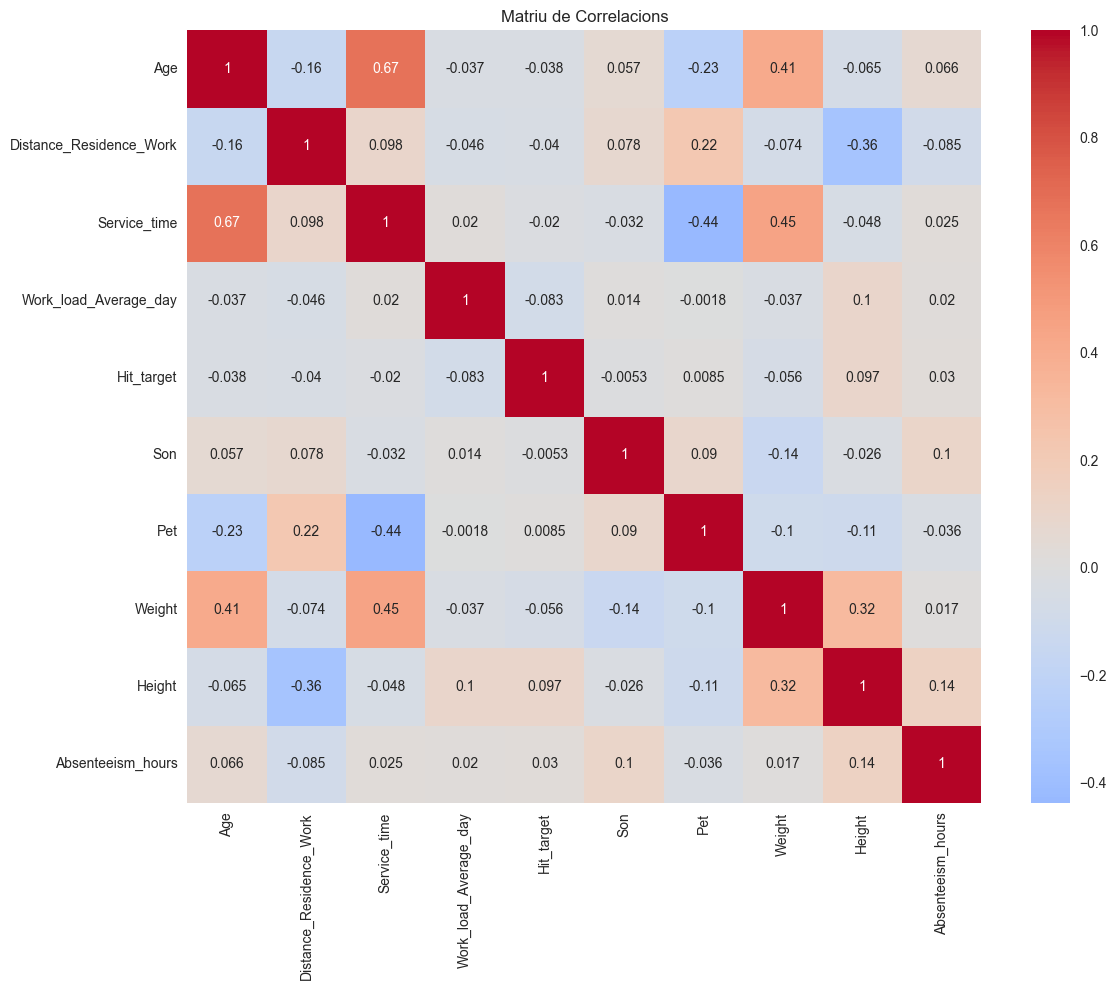

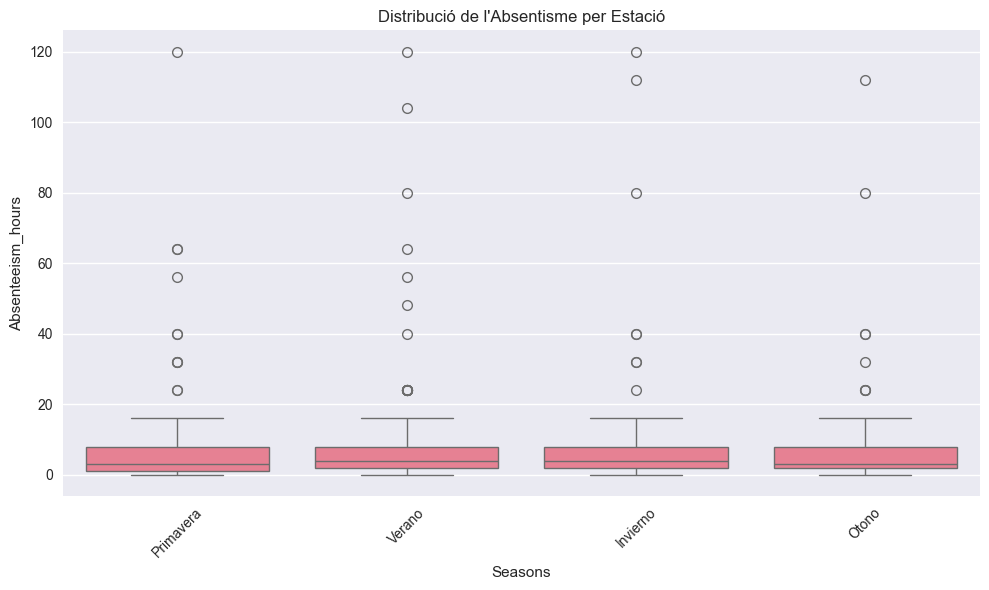

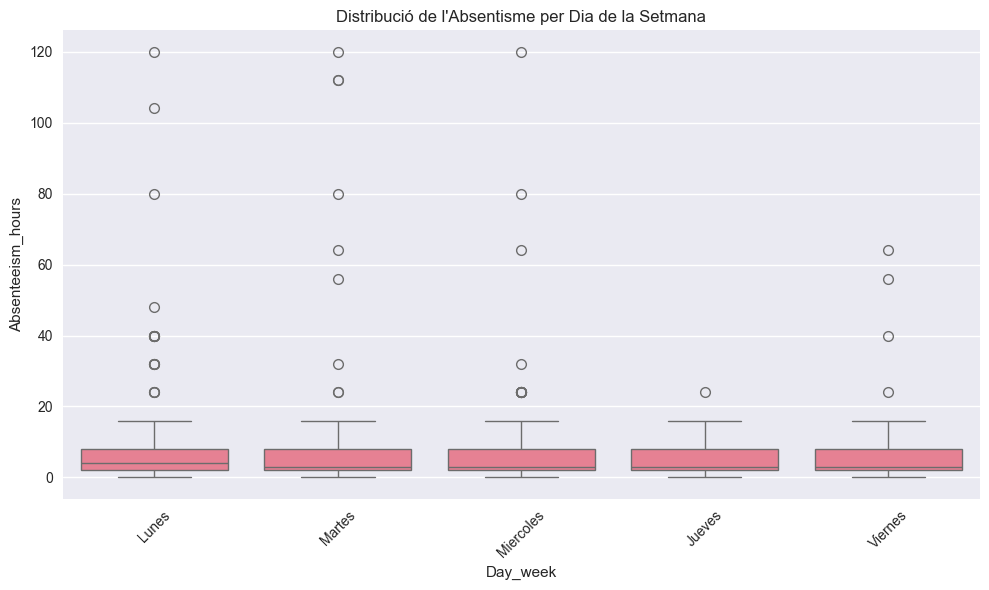

In [19]:
# Heatmap de correlacions
variables_numeriques = ['Age', 'Distance_Residence_Work', 'Service_time', 
                       'Work_load_Average_day', 'Hit_target', 'Son', 'Pet', 
                       'Weight', 'Height', 'Absenteeism_hours']

correlation_matrix = RRHH[variables_numeriques].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriu de Correlacions')
plt.tight_layout()
plt.show()

# Boxplot d'absentisme per estació
plt.figure(figsize=(10, 6))
sns.boxplot(x='Seasons', y='Absenteeism_hours', data=RRHH)
plt.title('Distribució de l\'Absentisme per Estació')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Boxplot d'absentisme per dia de la setmana
plt.figure(figsize=(10, 6))
sns.boxplot(x='Day_week', y='Absenteeism_hours', data=RRHH, order=['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes'])
plt.title('Distribució de l\'Absentisme per Dia de la Setmana')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sistema de Predicció (Model Bàsic)

Error Absolut Mitjà (MAE): 6.24
Arrel de l'Error Quadràtic Mitjà (RMSE): 14.26


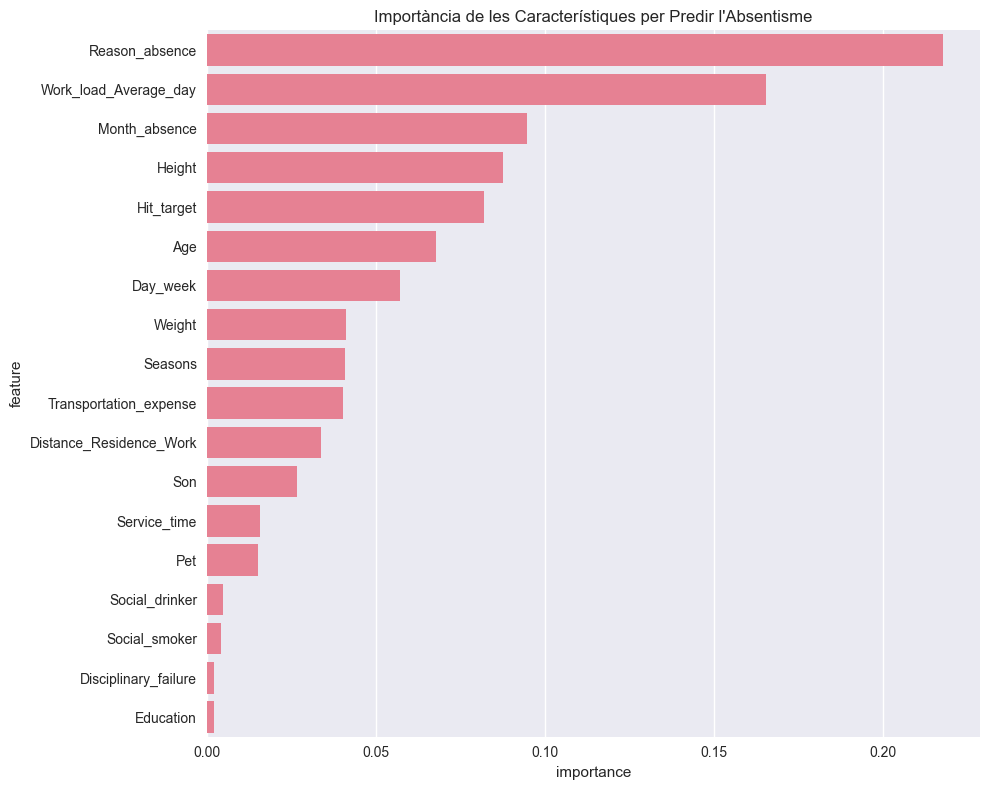

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Preparar les dades per a la predicció
# Convertir variables categòriques a numèriques
rrhh_model = RRHH.copy()
categorical_cols = ['Month_absence', 'Day_week', 'Seasons', 'Disciplinary_failure', 
                   'Education', 'Social_drinker', 'Social_smoker']

for col in categorical_cols:
    rrhh_model[col] = rrhh_model[col].astype('category').cat.codes

# Seleccionar característiques i variable objectiu
features = ['Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
           'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
           'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
           'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet',
           'Weight', 'Height']

X = rrhh_model[features]
y = rrhh_model['Absenteeism_hours']

# Dividir les dades
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Avaluar el model
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Error Absolut Mitjà (MAE): {mae:.2f}")
print(f"Arrel de l'Error Quadràtic Mitjà (RMSE): {rmse:.2f}")

# Importància de les característiques
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Importància de les Característiques per Predir l\'Absentisme')
plt.tight_layout()
plt.show()

Recomanacions basades en l'anàlisi

In [21]:
# Identificar mesos amb major absentisme per planificar recursos
absentisme_mensual = RRHH.groupby('Month_absence')['Absenteeism_hours'].sum().sort_values(ascending=False)
mesos_crítics = absentisme_mensual.head(3)
print("Mesos amb major absentisme (hores totals):")
for mes, hores in mesos_crítics.items():
    print(f"{mes}: {hores} hores")

# Identificar perfil d'empleats amb major absentisme
absentisme_per_empleat = RRHH.groupby('ID')['Absenteeism_hours'].sum().sort_values(ascending=False)
quantitat_absencies = RRHH.groupby('ID').size()  # Compta el nombre d'absències per empleat
total_hores_absencia = absentisme_per_empleat.sum()
empleats_al_risc = absentisme_per_empleat.head(10)

print("\nTop 10 empleats amb major absentisme:")
print("-" * 60)
print(f"{'ID':<10} {'Hores Totals':<15} {'% Total':<10} {'Núm. Absències':<15}")
print("-" * 60)

for empleat, hores in empleats_al_risc.items():
    percentatge = (hores / total_hores_absencia) * 100
    num_absencies = quantitat_absencies.get(empleat, 0)
    
    print(f"{empleat:<10} {hores:<15.1f} {percentatge:<10.1f} {num_absencies:<15}")

# Recomanació per a la creació d'un pool de treballadors temporals
print("\nRecomanació: Es recomana crear un pool de treballadors temporals per cobrir")
print("les necessitats durant els mesos d'alt absentisme, especialment a:")
for mes in mesos_crítics.index:
    print(f"- {mes}")

Mesos amb major absentisme (hores totals):
Marzo: 755 hores
Julio: 730 hores
Abril: 476 hores

Top 10 empleats amb major absentisme:
------------------------------------------------------------
ID         Hores Totals    % Total    Núm. Absències 
------------------------------------------------------------
14         476.0           9.4        29             
11         450.0           8.9        40             
3          444.0           8.8        97             
28         343.0           6.8        74             
34         333.0           6.6        50             
36         311.0           6.2        34             
20         306.0           6.1        42             
9          262.0           5.2        8              
24         251.0           5.0        28             
15         251.0           5.0        36             

Recomanació: Es recomana crear un pool de treballadors temporals per cobrir
les necessitats durant els mesos d'alt absentisme, especialment a:
- Marzo

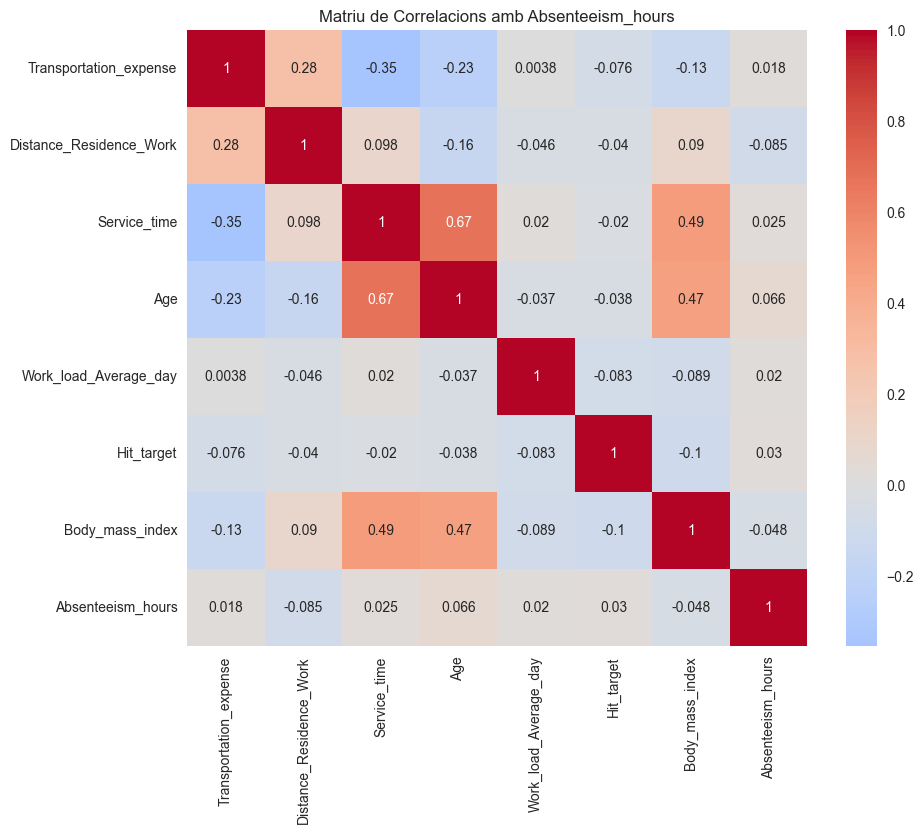

C:\Users\PC\AppData\Local\Temp\ipykernel_20872\169223107.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  absent_by_age = RRHH.groupby('Grup_edat')['Absenteeism_hours'].agg(['sum', 'mean', 'count']).round(2)


In [22]:
# Correlacions amb variables numèriques
variables = ['Transportation_expense', 'Distance_Residence_Work', 'Service_time', 'Age', 
             'Work_load_Average_day', 'Hit_target', 'Body_mass_index', 'Absenteeism_hours']
correlacions = RRHH[variables].corr()

# Visualització de matriu de correlacions
plt.figure(figsize=(10, 8))
sns.heatmap(correlacions, annot=True, cmap='coolwarm', center=0)
plt.title('Matriu de Correlacions amb Absenteeism_hours')
plt.show()

# Anàlisi per edat
RRHH['Grup_edat'] = pd.cut(RRHH['Age'], bins=[0, 25, 35, 45, 55, 100], 
                           labels=['<25', '26-35', '36-45', '46-55', '55+'])
absent_by_age = RRHH.groupby('Grup_edat')['Absenteeism_hours'].agg(['sum', 'mean', 'count']).round(2)

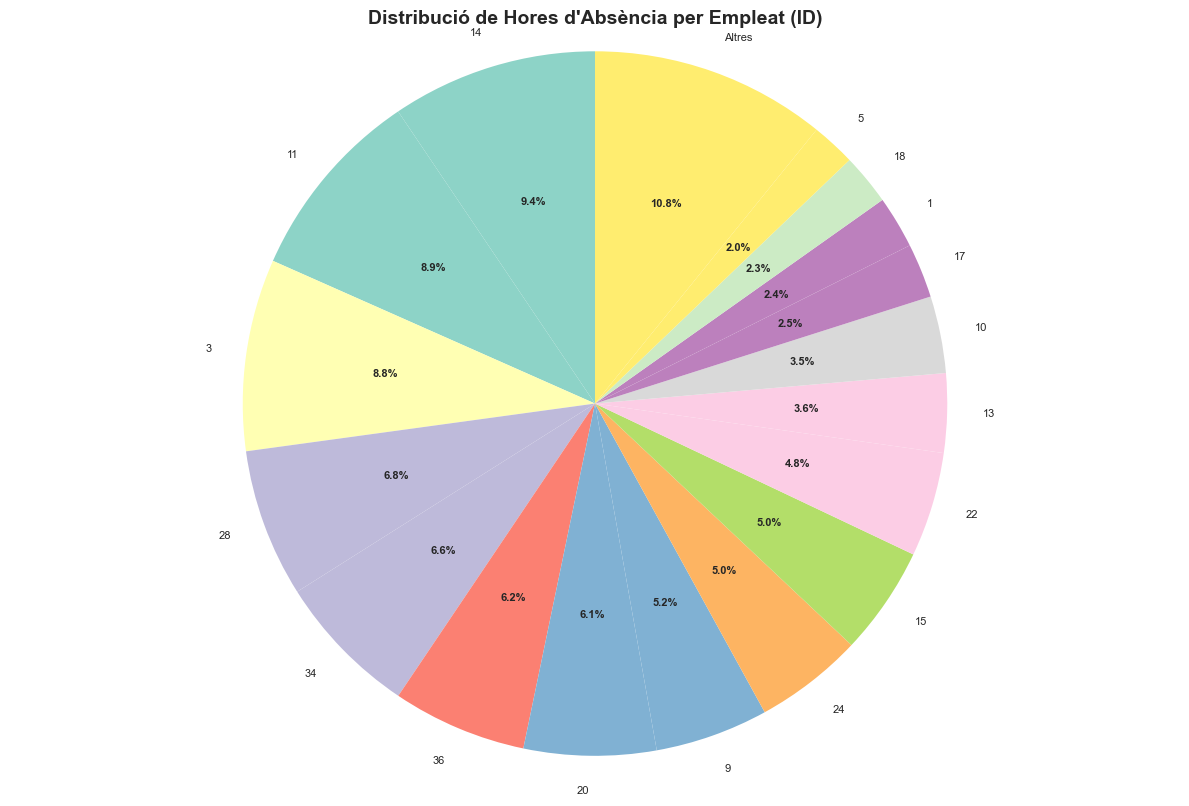

Total d'hores d'absència: 5043
Nombre d'empleats amb absències: 36
Empleats mostrats individualment: 17
Empleats agrupats com 'Altres': 19

Top empleats per hores d'absència:
1. ID 14: 476 hores (9.4%)
2. ID 11: 450 hores (8.9%)
3. ID 3: 444 hores (8.8%)
4. ID 28: 343 hores (6.8%)
5. ID 34: 333 hores (6.6%)
6. ID 36: 311 hores (6.2%)
7. ID 20: 306 hores (6.1%)
8. ID 9: 262 hores (5.2%)
9. ID 24: 251 hores (5.0%)
10. ID 15: 251 hores (5.0%)


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Agrupar les hores d'absència per cada empleat (ID)
absent_per_employee = RRHH.groupby('ID')['Absenteeism_hours'].sum().sort_values(ascending=False)

# Calcular el percentatge del total per cada empleat
total_hours = absent_per_employee.sum()
percent_per_employee = (absent_per_employee / total_hours) * 100

# Si hi ha molts empleats, podem agrupar els que tenen percentatges baixos en una categoria "Altres"
threshold = 2  # Percentatge mínim per mostrar individualment

# Separar els empleats amb percentatge significatiu i agrupar la resta
significant_employees = percent_per_employee[percent_per_employee >= threshold]
other_employees = percent_per_employee[percent_per_employee < threshold]

# Crear les dades per al gràfic
if len(other_employees) > 0:
    other_percentage = other_employees.sum()
    # Utilitzar pd.concat en lloc de l'obsolet append
    plot_data = pd.concat([significant_employees, pd.Series([other_percentage], index=['Altres'])])
else:
    plot_data = significant_employees

# Configurar l'estil del gràfic
plt.figure(figsize=(12, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(plot_data)))
wedges, texts, autotexts = plt.pie(plot_data.values, 
                                   labels=plot_data.index, 
                                   autopct='%1.1f%%', 
                                   colors=colors, 
                                   startangle=90)

# Millorar la llegibilitat
plt.setp(autotexts, size=8, weight="bold")
plt.setp(texts, size=8)

# Afegir un títol
plt.title('Distribució de Hores d\'Absència per Empleat (ID)', fontsize=14, fontweight='bold')

# Assegurar que el gràfic sigui un cercle
plt.axis('equal')

# Mostrar el gràfic
plt.tight_layout()
plt.show()

# Informació addicional
print(f"Total d'hores d'absència: {total_hours}")
print(f"Nombre d'empleats amb absències: {len(absent_per_employee)}")
print(f"Empleats mostrats individualment: {len(significant_employees)}")
print(f"Empleats agrupats com 'Altres': {len(other_employees)}")

# Opcional: Mostrar una taula amb els empleats més significatius
print("\nTop empleats per hores d'absència:")
top_employees = absent_per_employee.head(10)
for i, (emp_id, hours) in enumerate(top_employees.items(), 1):
    percentage = (hours / total_hours) * 100
    print(f"{i}. ID {emp_id}: {hours} hores ({percentage:.1f}%)")

=== ANÀLISI SOCIAL DRINKER ===

                Mitjana_hores  Total_hores  Comptador_absències  \
Social_drinker                                                    
0                        6.09         1870                  307   
1                        7.95         3173                  399   

                Nombre_empleats  
Social_drinker                   
0                            18  
1                            19  

Test t: t-statistic = -1.823, p-value = 0.0688


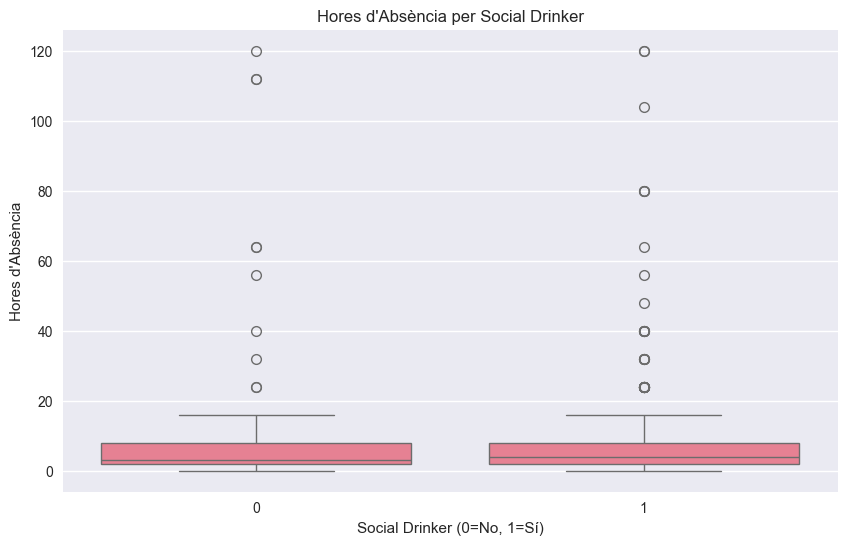

In [24]:
# Anàlisi bàsic de Social Drinker vs Absentisme
print("=== ANÀLISI SOCIAL DRINKER ===\n")

# Agrupar per Social_drinker
social_drinker_analysis = RRHH.groupby('Social_drinker').agg({
    'Absenteeism_hours': ['mean', 'sum', 'count'],
    'ID': 'nunique'
}).round(2)

social_drinker_analysis.columns = ['Mitjana_hores', 'Total_hores', 'Comptador_absències', 'Nombre_empleats']
print(social_drinker_analysis)

# Test estadístic
from scipy import stats

group_0 = RRHH[RRHH['Social_drinker'] == 0]['Absenteeism_hours']
group_1 = RRHH[RRHH['Social_drinker'] == 1]['Absenteeism_hours']

t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)
print(f"\nTest t: t-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")

# Gràfic bàsic
plt.figure(figsize=(10, 6))
sns.boxplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH)
plt.title('Hores d\'Absència per Social Drinker')
plt.xlabel('Social Drinker (0=No, 1=Sí)')
plt.ylabel('Hores d\'Absència')
plt.show()

=== ANÀLISI SOCIAL DRINKER vs ABSENTISME ===

Valors únics a Social_drinker: [1 0]
                Mitjana_hores  Total_hores  Comptador_absències  \
Social_drinker                                                    
0                        6.09         1870                  307   
1                        7.95         3173                  399   

                Desviació_estàndard  Nombre_empleats  
Social_drinker                                        
0                             12.98               18  
1                             14.04               19  

--- TEST ESTADÍSTIC ---
Social_drinker 1: n=399, mitjana=7.95, desviació=14.04
Social_drinker 0: n=307, mitjana=6.09, desviació=12.98

Test t per mostres independents:
t-statistic = 1.823, p-value = 0.0688
NO hi ha una diferència estadísticament significativa (p >= 0.05)


C:\Users\PC\AppData\Local\Temp\ipykernel_20872\3721365418.py:61: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH, ax=axes[1, 0], ci='sd')


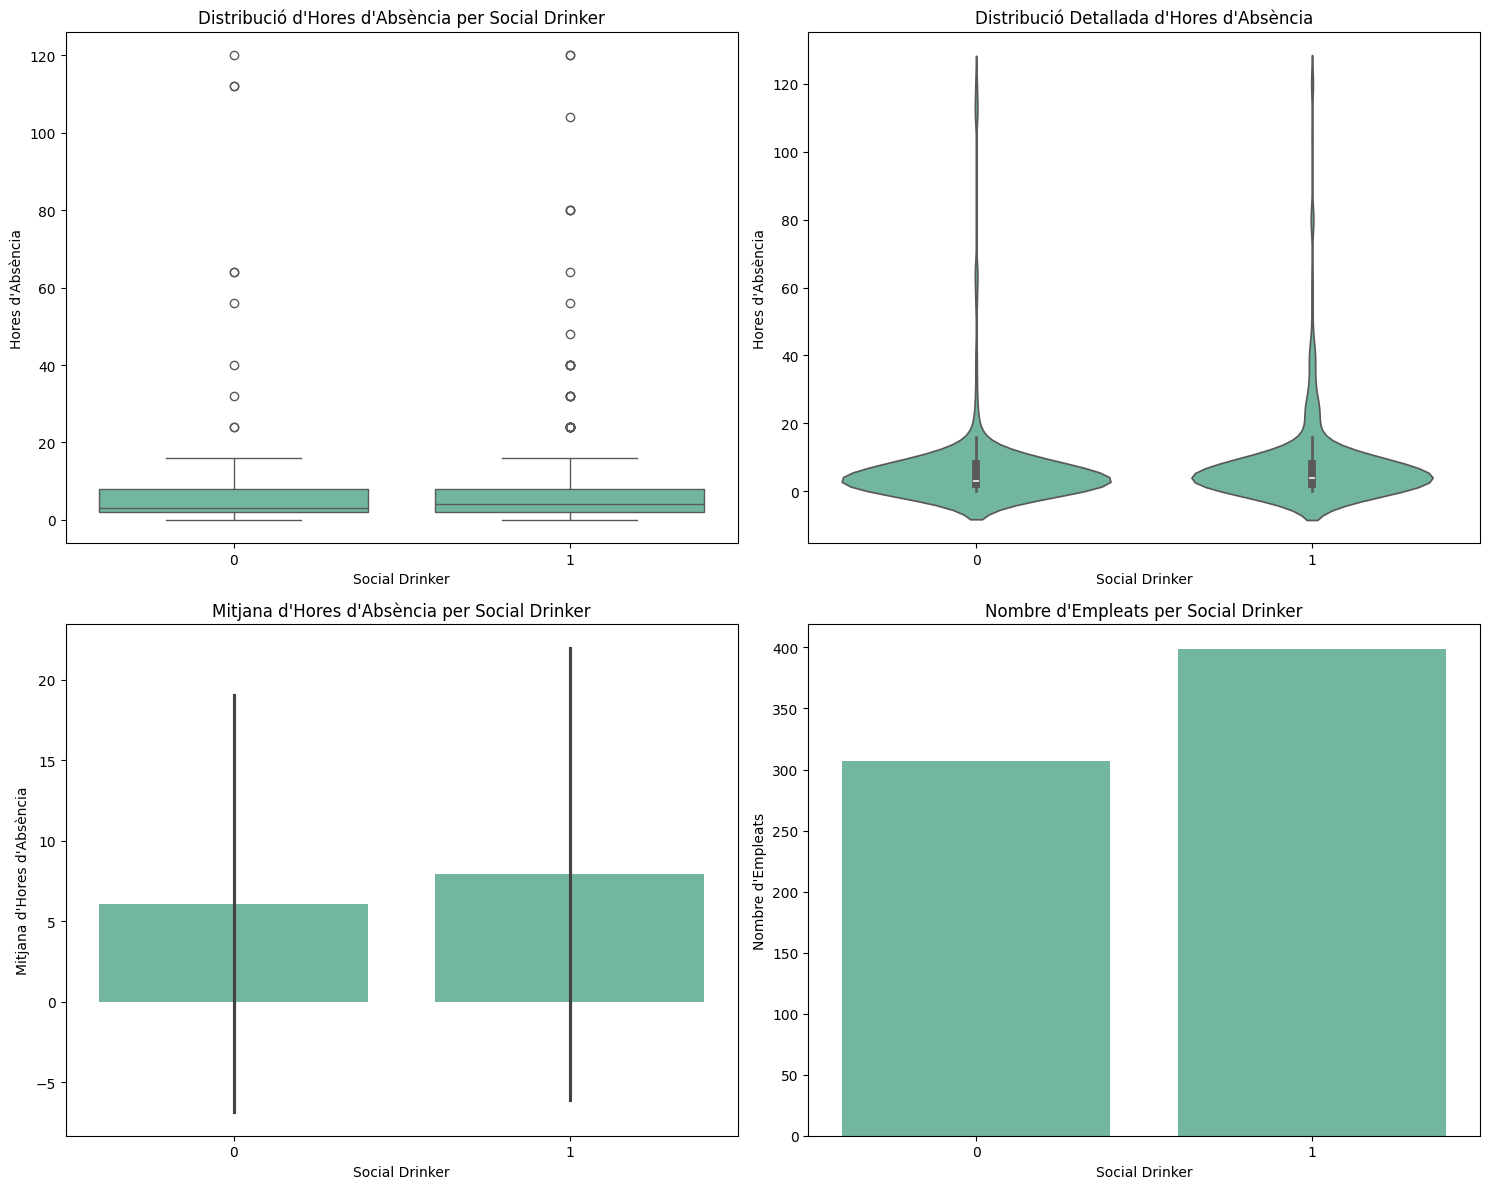


--- ANÀLISI COMBINAT ---


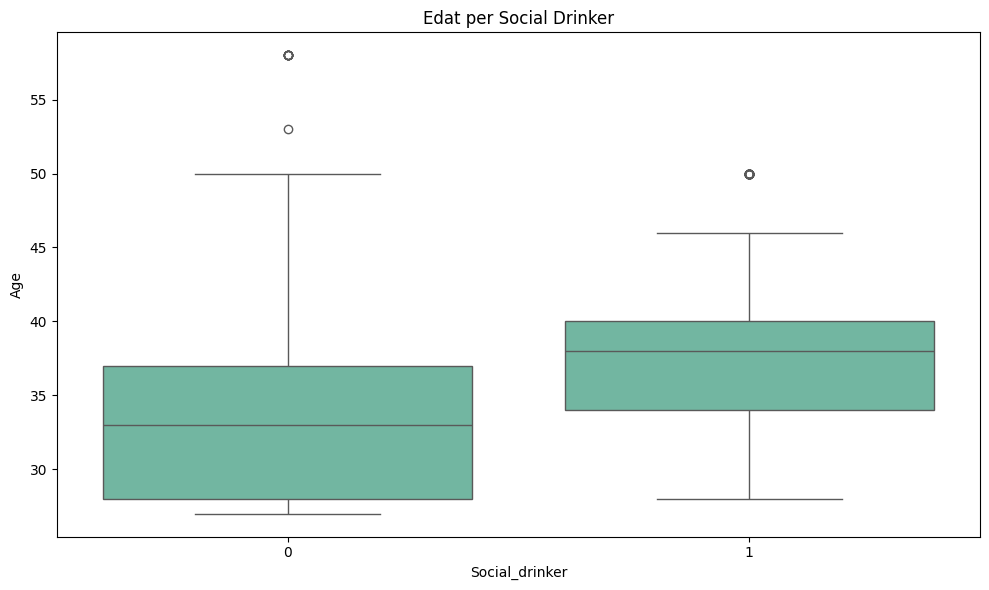

C:\Users\PC\AppData\Local\Temp\ipykernel_20872\3721365418.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reason_social = RRHH.groupby(['Reason_absence', 'Social_drinker'])['Absenteeism_hours'].sum().unstack()


<Figure size 1200x600 with 0 Axes>

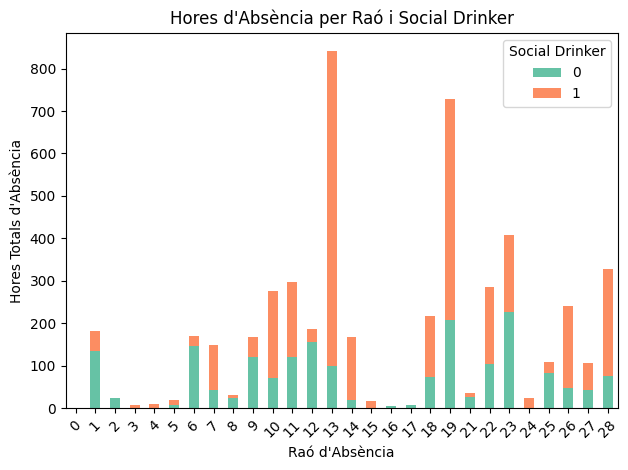


--- CORRELACIONS AMB ALTRES VARIABLES ---


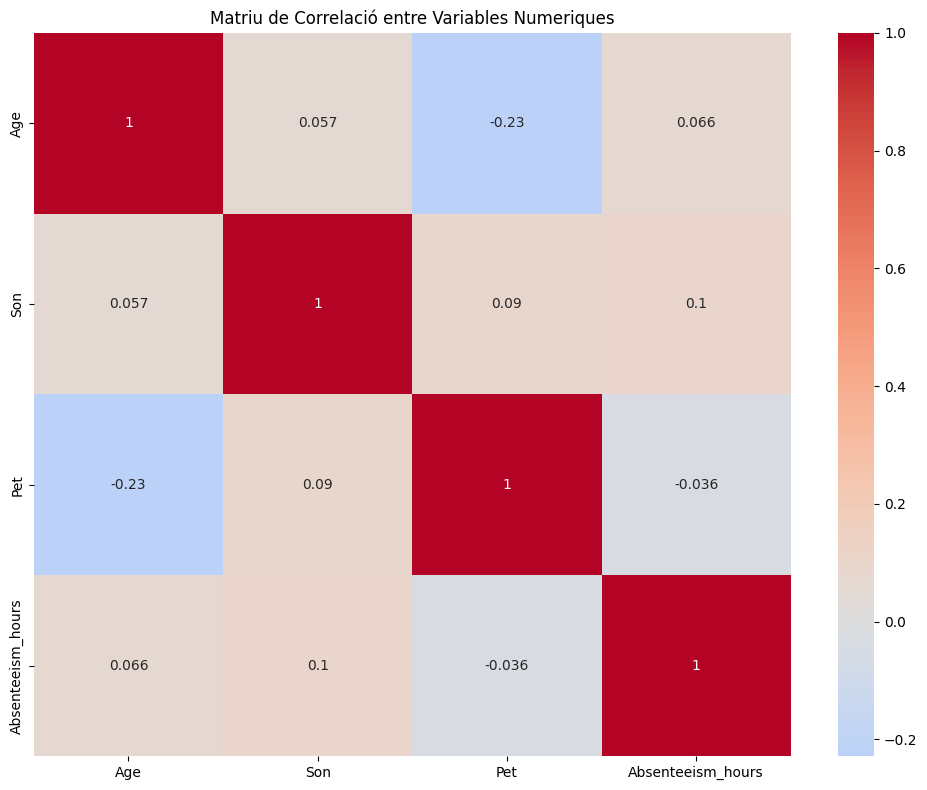


--- MODEL DE REGRESSIÓ ---
R² del model: 0.016
Coeficients del model:
  Social_drinker: 0.931
  Age: 0.097
  Son: 1.171
  Pet: -0.307
Intercept: 2.079


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Configurar l'estil dels gràfics
plt.style.use('default')
sns.set_palette("Set2")

# 1. Anàlisi bàsic per Social Drinker
print("=== ANÀLISI SOCIAL DRINKER vs ABSENTISME ===\n")

# Verificar els valors únics de la variable
print("Valors únics a Social_drinker:", RRHH['Social_drinker'].unique())

# Agrupar per Social_drinker
social_drinker_analysis = RRHH.groupby('Social_drinker').agg({
    'Absenteeism_hours': ['mean', 'sum', 'count', 'std'],
    'ID': 'nunique'
}).round(2)

social_drinker_analysis.columns = ['Mitjana_hores', 'Total_hores', 'Comptador_absències', 'Desviació_estàndard', 'Nombre_empleats']
print(social_drinker_analysis)

# 2. Test estadístic per comparar les mitjanes
print("\n--- TEST ESTADÍSTIC ---")
social_drinker_groups = []
for value in RRHH['Social_drinker'].unique():
    group_data = RRHH[RRHH['Social_drinker'] == value]['Absenteeism_hours']
    social_drinker_groups.append(group_data)
    print(f"Social_drinker {value}: n={len(group_data)}, mitjana={group_data.mean():.2f}, desviació={group_data.std():.2f}")

# Test t per mostres independents si només hi ha dos grups
if len(social_drinker_groups) == 2:
    t_stat, p_value = stats.ttest_ind(social_drinker_groups[0], social_drinker_groups[1], equal_var=False)
    print(f"\nTest t per mostres independents:")
    print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")
    
    if p_value < 0.05:
        print("Hi ha una diferència estadísticament significativa (p < 0.05)")
    else:
        print("NO hi ha una diferència estadísticament significativa (p >= 0.05)")

# 3. Visualitzacions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Boxplot
sns.boxplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH, ax=axes[0, 0])
axes[0, 0].set_title('Distribució d\'Hores d\'Absència per Social Drinker')
axes[0, 0].set_xlabel('Social Drinker')
axes[0, 0].set_ylabel('Hores d\'Absència')

# Violin plot
sns.violinplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH, ax=axes[0, 1])
axes[0, 1].set_title('Distribució Detallada d\'Hores d\'Absència')
axes[0, 1].set_xlabel('Social Drinker')
axes[0, 1].set_ylabel('Hores d\'Absència')

# Barplot amb mitjanes
sns.barplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH, ax=axes[1, 0], ci='sd')
axes[1, 0].set_title('Mitjana d\'Hores d\'Absència per Social Drinker')
axes[1, 0].set_xlabel('Social Drinker')
axes[1, 0].set_ylabel('Mitjana d\'Hores d\'Absència')

# Count plot
sns.countplot(x='Social_drinker', data=RRHH, ax=axes[1, 1])
axes[1, 1].set_title('Nombre d\'Empleats per Social Drinker')
axes[1, 1].set_xlabel('Social Drinker')
axes[1, 1].set_ylabel('Nombre d\'Empleats')

plt.tight_layout()
plt.show()

# 4. Anàlisi combinat amb altres variables
print("\n--- ANÀLISI COMBINAT ---")

# Social drinker i edat
plt.figure(figsize=(10, 6))
sns.boxplot(x='Social_drinker', y='Age', data=RRHH)
plt.title('Edat per Social Drinker')
plt.tight_layout()
plt.show()

# Social drinker i raons d'absència
if 'Reason_absence' in RRHH.columns:
    plt.figure(figsize=(12, 6))
    reason_social = RRHH.groupby(['Reason_absence', 'Social_drinker'])['Absenteeism_hours'].sum().unstack()
    reason_social.plot(kind='bar', stacked=True)
    plt.title('Hores d\'Absència per Raó i Social Drinker')
    plt.xlabel('Raó d\'Absència')
    plt.ylabel('Hores Totals d\'Absència')
    plt.legend(title='Social Drinker')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 5. Anàlisi de correlació amb altres variables sociodemogràfiques
print("\n--- CORRELACIONS AMB ALTRES VARIABLES ---")

variables_numeriques = ['Age', 'Son', 'Pet', 'Absenteeism_hours']
correlation_matrix = RRHH[variables_numeriques].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriu de Correlació entre Variables Numeriques')
plt.tight_layout()
plt.show()

# 6. Model de regressió per predir l'absentisme basat en Social Drinker i altres variables
print("\n--- MODEL DE REGRESSIÓ ---")

# Preparar les dades per a la regressió
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Crear variables dummy per a Social_drinker
X = pd.get_dummies(RRHH[['Social_drinker', 'Age', 'Son', 'Pet']], drop_first=True)
y = RRHH['Absenteeism_hours']

# Entrenar model de regressió
model = LinearRegression()
model.fit(X, y)

# Prediccions i R²
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print(f"R² del model: {r2:.3f}")
print("Coeficients del model:")
for i, col in enumerate(X.columns):
    print(f"  {col}: {model.coef_[i]:.3f}")

print(f"Intercept: {model.intercept_:.3f}")

=== ANÀLISI SOCIAL DRINKER vs ABSENTISME (36 EMPLEATS) ===

Valors únics a Social_drinker: [1 0]

Distribució d'empleats per Social Drinker:
Social_drinker 0: 18 empleats (50.0%)
Social_drinker 1: 19 empleats (52.8%)

Anàlisi d'absentisme per Social Drinker:
                Mitjana_hores  Total_hores  Comptador_absències  \
Social_drinker                                                    
0                        6.09         1870                  307   
1                        7.95         3173                  399   

                Desviació_estàndard  Nombre_empleats  
Social_drinker                                        
0                             12.98               18  
1                             14.04               19  

Anàlisi amb percentatges:
                Nombre_empleats  Total_hores  Percentatge_hores
Social_drinker                                                 
0                            18         1870          37.081103
1                            19  

C:\Users\PC\AppData\Local\Temp\ipykernel_20872\302695324.py:84: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH, ax=axes[1, 0], ci='sd')


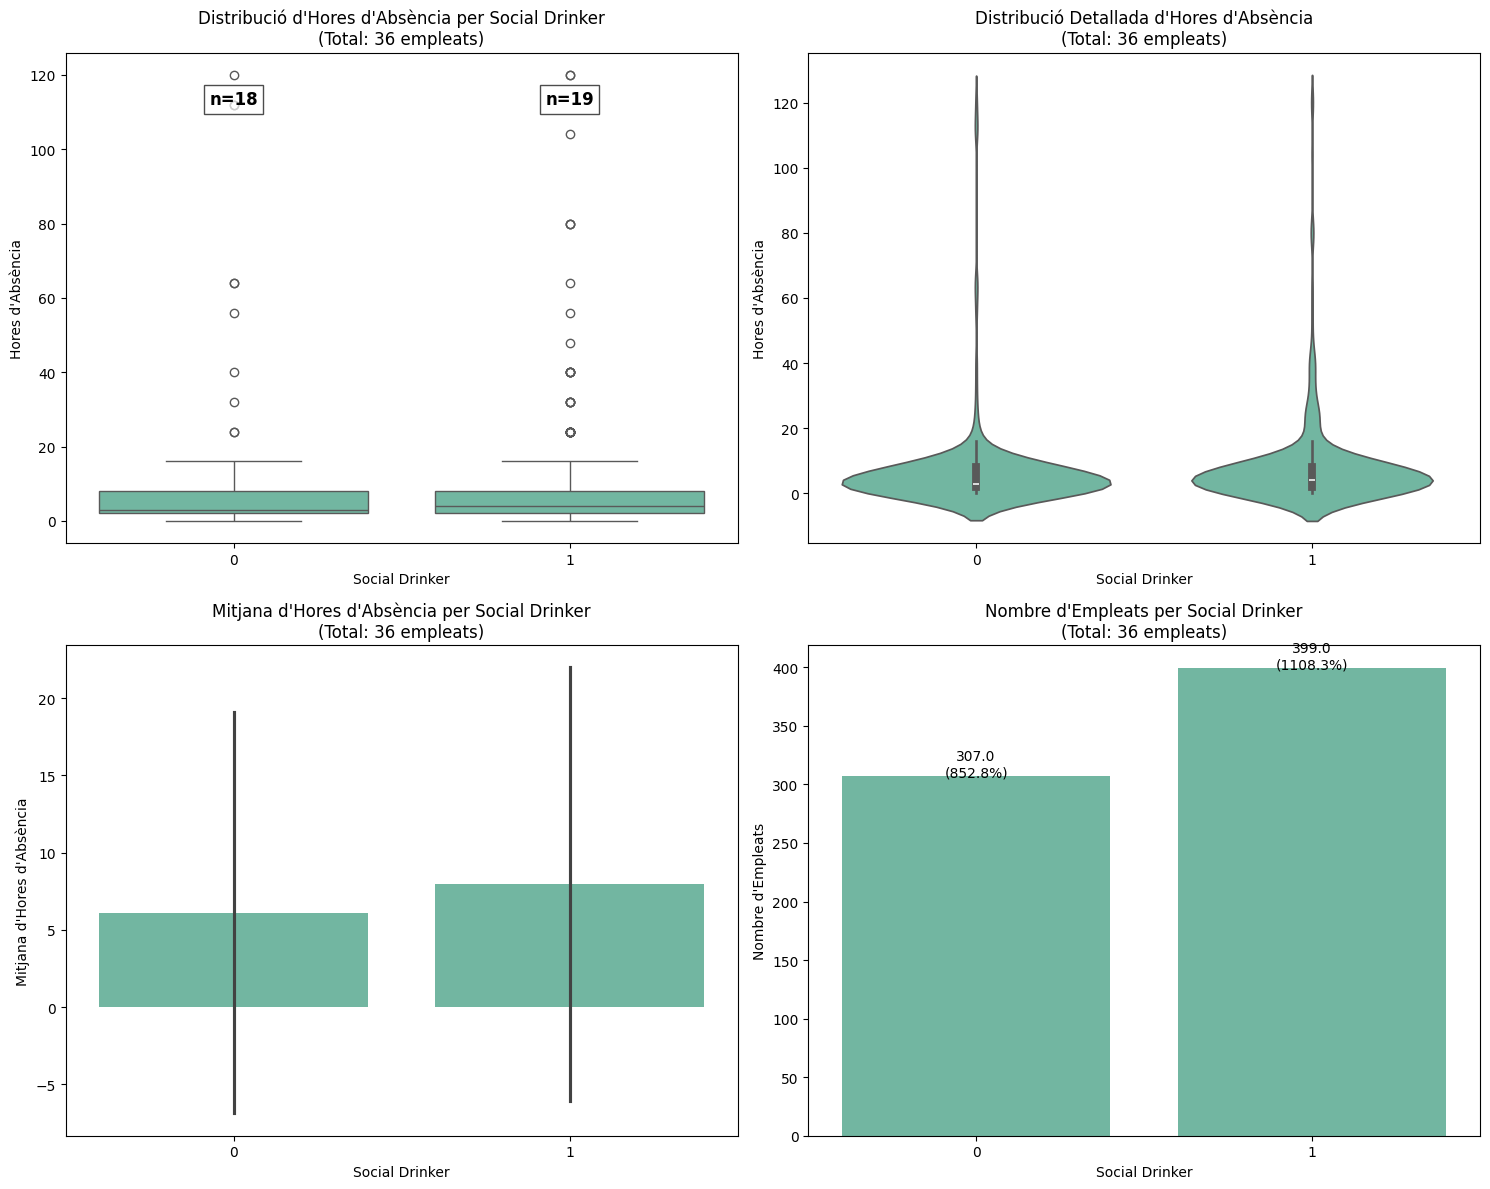


--- CÀRREGA D'ABSENTISME PER EMPLEAT ---
Mitjana d'hores d'absència per empleat Social_drinker 0: 105.06
Mitjana d'hores d'absència per empleat Social_drinker 1: 167.00

--- RECOMANACIONS ---
No hi ha diferències significatives en l'absentisme entre social drinkers i no social drinkers.
Recomanació: Centrar-se en altres factors que puguin influir en l'absentisme.

Els 19 social drinkers representen el 52.8% dels empleats
i contribueixen al 62.9% de les hores d'absència.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Configurar l'estil dels gràfics
plt.style.use('default')
sns.set_palette("Set2")

# 1. Anàlisi bàsic per Social Drinker amb context dels 36 empleats
print("=== ANÀLISI SOCIAL DRINKER vs ABSENTISME (36 EMPLEATS) ===\n")

# Verificar els valors únics de la variable
print("Valors únics a Social_drinker:", RRHH['Social_drinker'].unique())

# Calcular el nombre d'empleats únics per grup Social_drinker
empleats_por_grupo = RRHH.groupby('Social_drinker')['ID'].nunique()
total_empleats = 36  # Confirmat

print(f"\nDistribució d'empleats per Social Drinker:")
for grupo, cantidad in empleats_por_grupo.items():
    porcentaje = (cantidad / total_empleats) * 100
    print(f"Social_drinker {grupo}: {cantidad} empleats ({porcentaje:.1f}%)")

# Agrupar per Social_drinker
social_drinker_analysis = RRHH.groupby('Social_drinker').agg({
    'Absenteeism_hours': ['mean', 'sum', 'count', 'std'],
    'ID': 'nunique'
}).round(2)

social_drinker_analysis.columns = ['Mitjana_hores', 'Total_hores', 'Comptador_absències', 'Desviació_estàndard', 'Nombre_empleats']
print("\nAnàlisi d'absentisme per Social Drinker:")
print(social_drinker_analysis)

# Calcular el percentatge d'hores d'absència per grup
total_hores = social_drinker_analysis['Total_hores'].sum()
social_drinker_analysis['Percentatge_hores'] = (social_drinker_analysis['Total_hores'] / total_hores) * 100
print("\nAnàlisi amb percentatges:")
print(social_drinker_analysis[['Nombre_empleats', 'Total_hores', 'Percentatge_hores']])

# 2. Test estadístic per comparar les mitjanes
print("\n--- TEST ESTADÍSTIC ---")
social_drinker_groups = []
for value in RRHH['Social_drinker'].unique():
    group_data = RRHH[RRHH['Social_drinker'] == value]['Absenteeism_hours']
    social_drinker_groups.append(group_data)
    n_empleats = empleats_por_grupo[value]
    print(f"Social_drinker {value}: {n_empleats} empleats, mitjana={group_data.mean():.2f} hores")

# Test t per mostres independents si només hi ha dos grups
if len(social_drinker_groups) == 2:
    t_stat, p_value = stats.ttest_ind(social_drinker_groups[0], social_drinker_groups[1], equal_var=False)
    print(f"\nTest t per mostres independents:")
    print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")
    
    if p_value < 0.05:
        print("Hi ha una diferència estadísticament significativa (p < 0.05)")
    else:
        print("NO hi ha una diferència estadísticament significativa (p >= 0.05)")

# 3. Visualitzacions amb context dels 36 empleats
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Boxplot
sns.boxplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH, ax=axes[0, 0])
axes[0, 0].set_title('Distribució d\'Hores d\'Absència per Social Drinker\n(Total: 36 empleats)')
axes[0, 0].set_xlabel('Social Drinker')
axes[0, 0].set_ylabel('Hores d\'Absència')

# Afegir annotations amb el nombre d'empleats per grup
for i, grupo in enumerate(empleats_por_grupo.index):
    axes[0, 0].text(i, axes[0, 0].get_ylim()[1]*0.9, f'n={empleats_por_grupo[grupo]}', 
                   ha='center', va='center', fontweight='bold', fontsize=12,
                   bbox=dict(facecolor='white', alpha=0.7))

# Violin plot
sns.violinplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH, ax=axes[0, 1])
axes[0, 1].set_title('Distribució Detallada d\'Hores d\'Absència\n(Total: 36 empleats)')
axes[0, 1].set_xlabel('Social Drinker')
axes[0, 1].set_ylabel('Hores d\'Absència')

# Barplot amb mitjanes
sns.barplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH, ax=axes[1, 0], ci='sd')
axes[1, 0].set_title('Mitjana d\'Hores d\'Absència per Social Drinker\n(Total: 36 empleats)')
axes[1, 0].set_xlabel('Social Drinker')
axes[1, 0].set_ylabel('Mitjana d\'Hores d\'Absència')

# Count plot amb percentatges
counts = RRHH['Social_drinker'].value_counts()
ax = sns.countplot(x='Social_drinker', data=RRHH, ax=axes[1, 1])
axes[1, 1].set_title('Nombre d\'Empleats per Social Drinker\n(Total: 36 empleats)')
axes[1, 1].set_xlabel('Social Drinker')
axes[1, 1].set_ylabel('Nombre d\'Empleats')

# Afegir percentatges a les barres
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1,
            f'{height}\n({height/total_empleats*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

# 4. Anàlisi de la càrrega d'absentisme per empleat
print("\n--- CÀRREGA D'ABSENTISME PER EMPLEAT ---")

# Calcular hores totals d'absència per empleat
absentisme_per_empleat = RRHH.groupby('ID')['Absenteeism_hours'].sum()

# Separar per Social_drinker
social_drinker_0_empleats = RRHH[RRHH['Social_drinker'] == 0]['ID'].unique()
social_drinker_1_empleats = RRHH[RRHH['Social_drinker'] == 1]['ID'].unique()

absentisme_sd_0 = absentisme_per_empleat[absentisme_per_empleat.index.isin(social_drinker_0_empleats)]
absentisme_sd_1 = absentisme_per_empleat[absentisme_per_empleat.index.isin(social_drinker_1_empleats)]

print(f"Mitjana d'hores d'absència per empleat Social_drinker 0: {absentisme_sd_0.mean():.2f}")
print(f"Mitjana d'hores d'absència per empleat Social_drinker 1: {absentisme_sd_1.mean():.2f}")

# 5. Recomanacions basades en l'anàlisi
print("\n--- RECOMANACIONS ---")

# Identificar si hi ha diferències significatives
if len(social_drinker_groups) == 2 and p_value < 0.05:
    mitjana_0 = social_drinker_groups[0].mean()
    mitjana_1 = social_drinker_groups[1].mean()
    
    if mitjana_0 > mitjana_1:
        print("Els empleats que NO són social drinkers tenen significativament MÉS absentisme.")
        print("Recomanació: Investigar les causes d'absentisme en aquest grup i implementar programes de benestar.")
    else:
        print("Els empleats que SÓN social drinkers tenen significativament MÉS absentisme.")
        print("Recomanació: Considerar programes de suport per a la reducció del consum d'alcohol.")
else:
    print("No hi ha diferències significatives en l'absentisme entre social drinkers i no social drinkers.")
    print("Recomanació: Centrar-se en altres factors que puguin influir en l'absentisme.")

print(f"\nEls {empleats_por_grupo.get(1, 0)} social drinkers representen el {empleats_por_grupo.get(1, 0)/total_empleats*100:.1f}% dels empleats")
print(f"i contribueixen al {social_drinker_analysis.loc[1, 'Percentatge_hores'] if 1 in social_drinker_analysis.index else 0:.1f}% de les hores d'absència.")

=== ANÀLISI ESTADÍSTIC COMPLETA ===

1. VERIFICACIÓ DE SUPÒSITS:
Normalitat grup Social_drinker=0: p=0.0000
Normalitat grup Social_drinker=1: p=0.0000
Homogeneïtat de variàncies (Levene): p=0.1014

2. TEST ESTADÍSTIC PRINCIPAL:
Test utilitzat: t-test (variàncies iguals)
t-statistic = -1.804, p-value = 0.0716

3. MIDA DE L'EFECTE:
Cohen's d: -0.137
Interpretació: efecte petit

4. TEST NO PARAMÈTRIC DE CONFIRMACIÓ:
Mann-Whitney U: 53585.5, p=0.0036

5. INTERVAL DE CONFIANÇA:
Diferència de mitjanes: -1.86
Interval de confiança al 95%: [-3.88, 0.16]

6. INTERPRETACIÓ FINAL:
NO hi ha evidència estadística de diferència en hores d'absència entre bevedors socials i no bevedors.
El resultat no és estadísticament significatiu (p=0.0716)


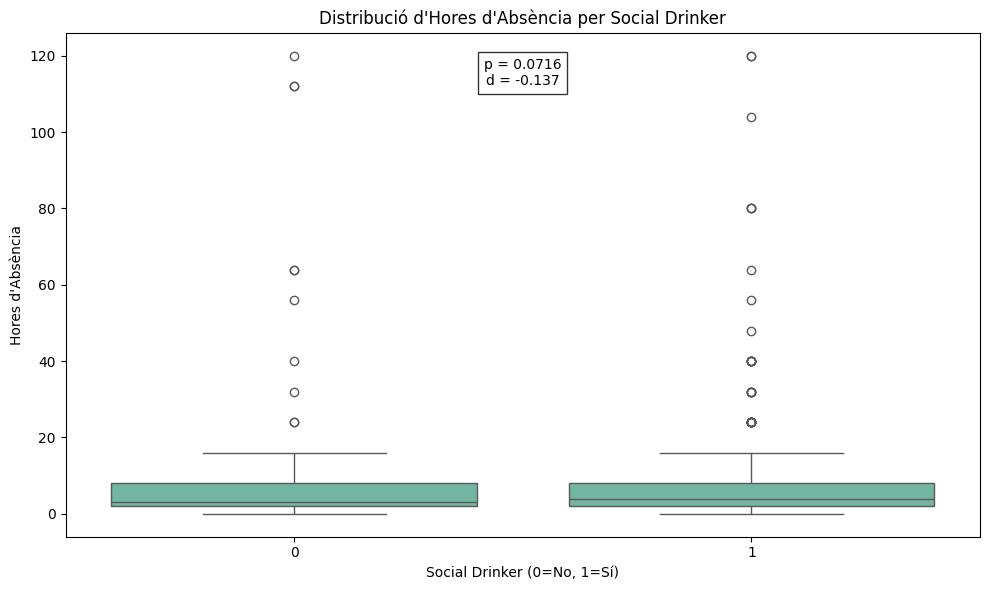

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Configurar l'estil dels gràfics
plt.style.use('default')
sns.set_palette("Set2")

# Definir la funció per calcular Cohen's d
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

# Assegurar-nos que tenim les dades preparades
group_0 = RRHH[RRHH['Social_drinker'] == 0]['Absenteeism_hours']
group_1 = RRHH[RRHH['Social_drinker'] == 1]['Absenteeism_hours']

# Anàlisi exhaustiva de la relació Social Drinker - Absències
print("=== ANÀLISI ESTADÍSTIC COMPLETA ===")

# 1. Verificació de supòsits
print("\n1. VERIFICACIÓ DE SUPÒSITS:")

# Normalitat (Shapiro-Wilk test)
_, p_normal_0 = stats.shapiro(group_0)
_, p_normal_1 = stats.shapiro(group_1)
print(f"Normalitat grup Social_drinker=0: p={p_normal_0:.4f}")
print(f"Normalitat grup Social_drinker=1: p={p_normal_1:.4f}")

# Homogeneïtat de variàncies (Levene's test)
_, p_levene = stats.levene(group_0, group_1)
print(f"Homogeneïtat de variàncies (Levene): p={p_levene:.4f}")

# 2. Test estadístic principal
print("\n2. TEST ESTADÍSTIC PRINCIPAL:")
# Triar el test adequat basat en els supòsits
if p_levene > 0.05:  # Variàncies iguals
    t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=True)
    test_type = "t-test (variàncies iguals)"
else:  # Variàncies diferents
    t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)
    test_type = "t-test (Welch, variàncies diferents)"

print(f"Test utilitzat: {test_type}")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")

# 3. Mida de l'efecte
print("\n3. MIDA DE L'EFECTE:")
d = cohens_d(group_0, group_1)
print(f"Cohen's d: {d:.3f}")

# Interpretació de la mida de l'efecte
if abs(d) < 0.2:
    effect_size = "efecte petit"
elif abs(d) < 0.5:
    effect_size = "efecte mitjà"
elif abs(d) < 0.8:
    effect_size = "efecte gran"
else:
    effect_size = "efecte molt gran"
print(f"Interpretació: {effect_size}")

# 4. Test no paramètric com a confirmació (Mann-Whitney U)
print("\n4. TEST NO PARAMÈTRIC DE CONFIRMACIÓ:")
u_stat, p_mannwhitney = stats.mannwhitneyu(group_0, group_1)
print(f"Mann-Whitney U: {u_stat}, p={p_mannwhitney:.4f}")

# 5. Interval de confiança
print("\n5. INTERVAL DE CONFIANÇA:")
n0, n1 = len(group_0), len(group_1)
std0, std1 = np.std(group_0, ddof=1), np.std(group_1, ddof=1)
mean_diff = np.mean(group_0) - np.mean(group_1)

# Error estàndard de la diferència
if p_levene > 0.05:  # Variàncies iguals
    pooled_se = np.sqrt(((n0-1)*std0**2 + (n1-1)*std1**2) / (n0+n1-2))
    se_diff = pooled_se * np.sqrt(1/n0 + 1/n1)
else:  # Variàncies diferents
    se_diff = np.sqrt(std0**2/n0 + std1**2/n1)

# Interval de confiança al 95%
ci_low = mean_diff - 1.96 * se_diff
ci_high = mean_diff + 1.96 * se_diff
print(f"Diferència de mitjanes: {mean_diff:.2f}")
print(f"Interval de confiança al 95%: [{ci_low:.2f}, {ci_high:.2f}]")

# 6. Interpretació final
print("\n6. INTERPRETACIÓ FINAL:")
if p_value < 0.05:
    if mean_diff > 0:
        print("Hi ha evidència estadística que els NO bevedors socials tenen MÉS hores d'absència.")
    else:
        print("Hi ha evidència estadística que els bevedors socials tenen MÉS hores d'absència.")
    print(f"Aquesta diferència és estadísticament significativa (p={p_value:.4f})")
    print(f"La mida de l'efecte és {effect_size} (d={d:.3f})")
else:
    print("NO hi ha evidència estadística de diferència en hores d'absència entre bevedors socials i no bevedors.")
    print(f"El resultat no és estadísticament significatiu (p={p_value:.4f})")

# 7. Visualització dels resultats
plt.figure(figsize=(10, 6))
sns.boxplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH)
plt.title('Distribució d\'Hores d\'Absència per Social Drinker')
plt.xlabel('Social Drinker (0=No, 1=Sí)')
plt.ylabel('Hores d\'Absència')

# Afegir annotations amb informació estadística
if p_value < 0.05:
    sig_text = f"p = {p_value:.4f}*\nd = {d:.3f}"
else:
    sig_text = f"p = {p_value:.4f}\nd = {d:.3f}"

plt.text(0.5, 0.95, sig_text, transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8), ha='center', va='top')

plt.tight_layout()
plt.show()

=== ANÀLISI DE RELACIONS ESPECÍFIQUES ===

1. RELACIÓ ENTRE EDAT I MOTIU D'ABSÈNCIA 13

Nombre d'absències pel motiu 13: 55
Nombre d'absències per altres motius: 651

Estadístics d'edat per absències del motiu 13:
Mitjana: 36.49 anys
Desviació estàndard: 6.65

Estadístics d'edat per absències d'altres motius:
Mitjana: 36.48 anys
Desviació estàndard: 6.56

Test t (Welch): t-statistic = 0.014, p-value = 0.9888
Cohen's d: 0.002
NO hi ha diferència significativa en l'edat entre les persones amb absències pel motiu 13 i les altres.


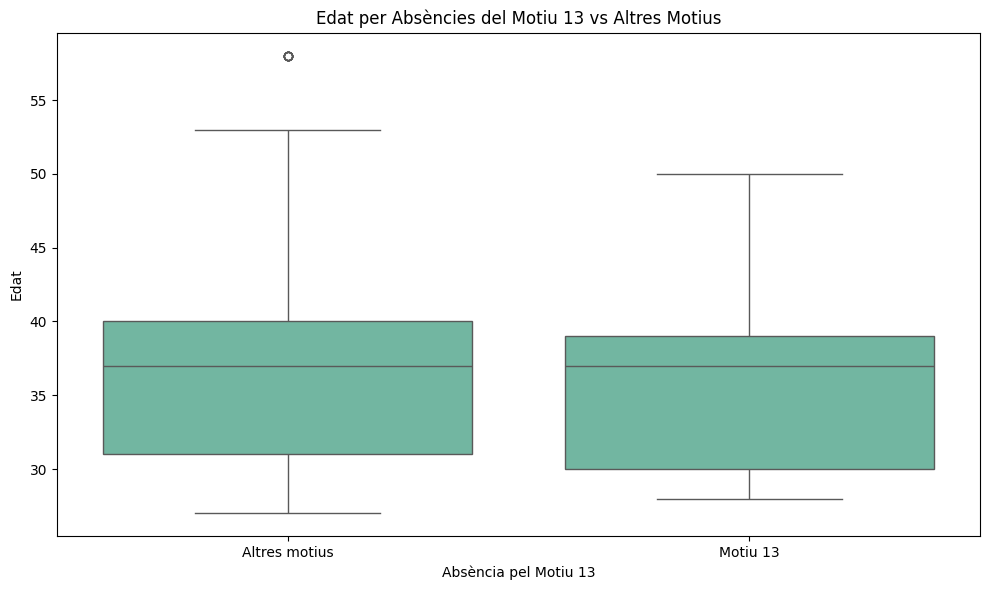


2. RELACIÓ ENTRE SOCIAL DRINKER I MOTIU D'ABSÈNCIA 19

Taula de contingència:
Motiu_19        False  True 
Social_drinker              
0                 296     11
1                 370     29

Total d'absències pel motiu 19: 40

Test Chi-quadrat: χ² = 3.746, p-value = 0.0529
Phi de Cramér: 0.073
Interpretació: efecte petit
NO hi ha associació significativa entre ser social drinker i les absències pel motiu 19.


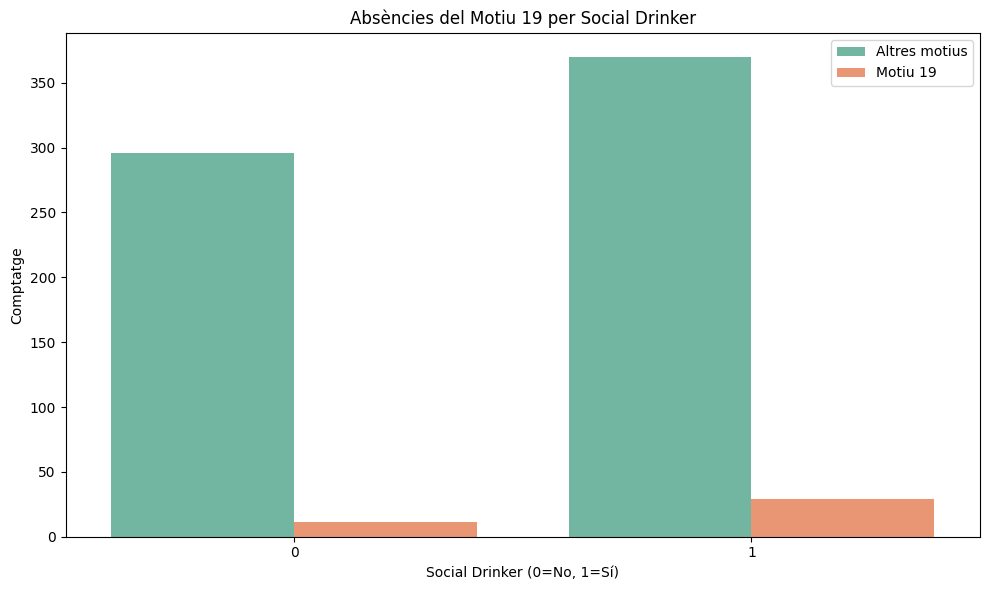


3. ANÀLISI ADDICIONAL: DISTRIBUCIÓ D'EDAT PER TIPUS DE MOTIU

Estadístics d'edat per motiu d'absència:
                 mean    std  count
Reason_absence                     
4               45.00   5.66      2
5               41.67   7.23      3
14              41.05   6.53     19
3               40.00    NaN      1
17              40.00    NaN      1
0               39.60   7.35     43
15              39.50   4.95      2
6               38.50  12.51      8
26              37.85   5.41     33
1               37.69   9.07     16
18              37.62   8.68     21
28              37.42   4.93    108
16              37.33   4.62      3
21              37.17   3.71      6
9               36.75   6.13      4
8               36.50   4.42      6
13              36.49   6.65     55
25              36.16   8.10     31
12              36.12   9.78      8
10              35.96   5.69     25
23              35.74   7.31    142
19              35.45   5.74     40
11              35.12   5.15    

C:\Users\PC\AppData\Local\Temp\ipykernel_20872\2944095898.py:128: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edat_per_motiu = RRHH.groupby('Reason_absence')['Age'].agg(['mean', 'std', 'count']).round(2)


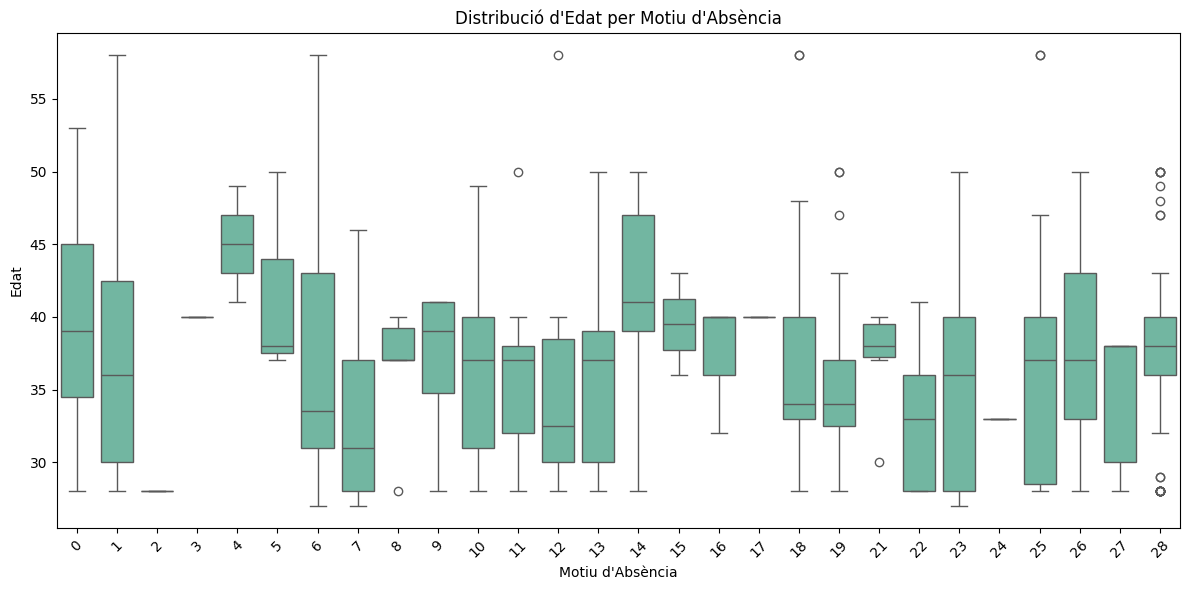


4. ANÀLISI ADDICIONAL: SOCIAL DRINKER PER TIPUS DE MOTIU

Proporció de social drinkers per motiu d'absència:
Motiu 3: 1.000
Motiu 15: 1.000
Motiu 24: 1.000
Motiu 28: 0.769
Motiu 26: 0.758
Motiu 19: 0.725
Motiu 14: 0.684
Motiu 22: 0.676
Motiu 0: 0.674
Motiu 5: 0.667
Motiu 13: 0.618
Motiu 10: 0.560
Motiu 27: 0.511
Motiu 12: 0.500
Motiu 4: 0.500
Motiu 9: 0.500
Motiu 23: 0.458
Motiu 18: 0.429
Motiu 11: 0.423
Motiu 7: 0.400
Motiu 6: 0.375
Motiu 21: 0.333
Motiu 1: 0.312
Motiu 25: 0.194
Motiu 8: 0.167
Motiu 2: 0.000
Motiu 16: 0.000
Motiu 17: 0.000


C:\Users\PC\AppData\Local\Temp\ipykernel_20872\2944095898.py:146: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  social_drinker_per_motiu = RRHH.groupby('Reason_absence')['Social_drinker'].mean().sort_values(ascending=False)
C:\Users\PC\AppData\Local\Temp\ipykernel_20872\2944095898.py:153: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Reason_absence', y='Social_drinker', data=RRHH, ci=None)


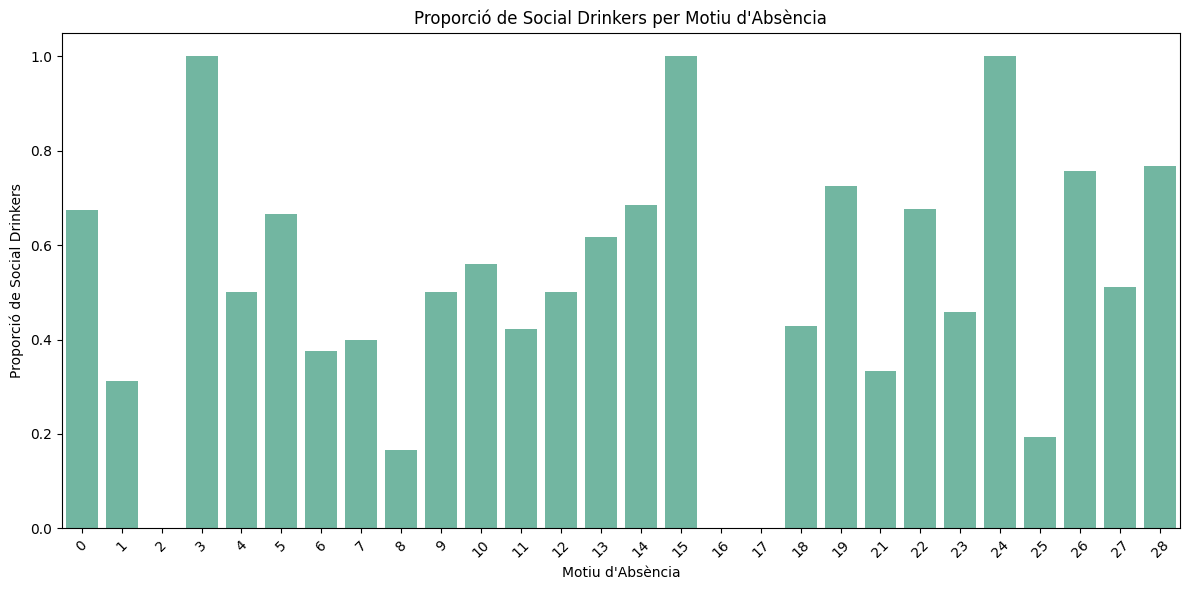

In [28]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Configurar l'estil dels gràfics
plt.style.use('default')
sns.set_palette("Set2")

print("=== ANÀLISI DE RELACIONS ESPECÍFIQUES ===\n")

# 1. RELACIÓ ENTRE EDAT I MOTIU 13
print("1. RELACIÓ ENTRE EDAT I MOTIU D'ABSÈNCIA 13\n")

# Crear variable binària per al motiu 13
RRHH['Motiu_13'] = RRHH['Reason_absence'] == 13

# Separar les dades
edat_motiu_13 = RRHH[RRHH['Motiu_13'] == True]['Age']
edat_no_motiu_13 = RRHH[RRHH['Motiu_13'] == False]['Age']

print(f"Nombre d'absències pel motiu 13: {len(edat_motiu_13)}")
print(f"Nombre d'absències per altres motius: {len(edat_no_motiu_13)}")

# Estadístics descriptius
print(f"\nEstadístics d'edat per absències del motiu 13:")
print(f"Mitjana: {edat_motiu_13.mean():.2f} anys")
print(f"Desviació estàndard: {edat_motiu_13.std():.2f}")

print(f"\nEstadístics d'edat per absències d'altres motius:")
print(f"Mitjana: {edat_no_motiu_13.mean():.2f} anys")
print(f"Desviació estàndard: {edat_no_motiu_13.std():.2f}")

# Test estadístic (t-test per mostres independents)
t_stat, p_value = stats.ttest_ind(edat_motiu_13, edat_no_motiu_13, equal_var=False)
print(f"\nTest t (Welch): t-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")

# Mida de l'efecte (Cohen's d)
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

d = cohens_d(edat_motiu_13, edat_no_motiu_13)
print(f"Cohen's d: {d:.3f}")

# Interpretació
if p_value < 0.05:
    if np.mean(edat_motiu_13) > np.mean(edat_no_motiu_13):
        print("Les persones amb absències pel motiu 13 són significativament MÉS grans.")
    else:
        print("Les persones amb absències pel motiu 13 són significativament MÉS joves.")
else:
    print("NO hi ha diferència significativa en l'edat entre les persones amb absències pel motiu 13 i les altres.")

# Visualització
plt.figure(figsize=(10, 6))
sns.boxplot(x='Motiu_13', y='Age', data=RRHH)
plt.title('Edat per Absències del Motiu 13 vs Altres Motius')
plt.xlabel('Absència pel Motiu 13')
plt.ylabel('Edat')
plt.xticks([0, 1], ['Altres motius', 'Motiu 13'])
plt.tight_layout()
plt.show()

# 2. RELACIÓ ENTRE SOCIAL DRINKER I MOTIU 19
print("\n2. RELACIÓ ENTRE SOCIAL DRINKER I MOTIU D'ABSÈNCIA 19\n")

# Crear variable binària per al motiu 19
RRHH['Motiu_19'] = RRHH['Reason_absence'] == 19

# Crear taula de contingència
contingency_table = pd.crosstab(RRHH['Social_drinker'], RRHH['Motiu_19'])
print("Taula de contingència:")
print(contingency_table)
print(f"\nTotal d'absències pel motiu 19: {contingency_table[True].sum()}")

# Test d'independència (Chi-quadrat)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nTest Chi-quadrat: χ² = {chi2:.3f}, p-value = {p_value:.4f}")

# Mida de l'efecte (Phi de Cramér)
n = contingency_table.sum().sum()
phi = np.sqrt(chi2 / n)
print(f"Phi de Cramér: {phi:.3f}")

# Interpretació de la mida de l'efecte
if phi < 0.1:
    effect_size = "efecte petit"
elif phi < 0.3:
    effect_size = "efecte mitjà"
else:
    effect_size = "efecte gran"
print(f"Interpretació: {effect_size}")

# Interpretació
if p_value < 0.05:
    # Calcular les proporcions
    prop_drinker_motiu19 = contingency_table.loc[1, True] / contingency_table.loc[1].sum()
    prop_no_drinker_motiu19 = contingency_table.loc[0, True] / contingency_table.loc[0].sum()
    
    print(f"Proporció de social drinkers amb absències del motiu 19: {prop_drinker_motiu19:.3f}")
    print(f"Proporció de no social drinkers amb absències del motiu 19: {prop_no_drinker_motiu19:.3f}")
    
    if prop_drinker_motiu19 > prop_no_drinker_motiu19:
        print("Els social drinkers tenen significativament MÉS probabilitat d'absències pel motiu 19.")
    else:
        print("Els social drinkers tenen significativament MENYS probabilitat d'absències pel motiu 19.")
else:
    print("NO hi ha associació significativa entre ser social drinker i les absències pel motiu 19.")

# Visualització
plt.figure(figsize=(10, 6))
sns.countplot(x='Social_drinker', hue='Motiu_19', data=RRHH)
plt.title('Absències del Motiu 19 per Social Drinker')
plt.xlabel('Social Drinker (0=No, 1=Sí)')
plt.ylabel('Comptatge')
plt.legend(['Altres motius', 'Motiu 19'])
plt.tight_layout()
plt.show()

# 3. ANÀLISI ADDICIONAL: DISTRIBUCIÓ D'EDAT PER MOTIUS
print("\n3. ANÀLISI ADDICIONAL: DISTRIBUCIÓ D'EDAT PER TIPUS DE MOTIU\n")

# Agrupar per motiu i calcular estadístics d'edat
edat_per_motiu = RRHH.groupby('Reason_absence')['Age'].agg(['mean', 'std', 'count']).round(2)
print("Estadístics d'edat per motiu d'absència:")
print(edat_per_motiu.sort_values('mean', ascending=False))

# Visualització
plt.figure(figsize=(12, 6))
sns.boxplot(x='Reason_absence', y='Age', data=RRHH)
plt.title('Distribució d\'Edat per Motiu d\'Absència')
plt.xlabel('Motiu d\'Absència')
plt.ylabel('Edat')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. ANÀLISI ADDICIONAL: SOCIAL DRINKER PER MOTIUS
print("\n4. ANÀLISI ADDICIONAL: SOCIAL DRINKER PER TIPUS DE MOTIU\n")

# Calcular proporció de social drinkers per motiu
social_drinker_per_motiu = RRHH.groupby('Reason_absence')['Social_drinker'].mean().sort_values(ascending=False)
print("Proporció de social drinkers per motiu d'absència:")
for motiu, proporcio in social_drinker_per_motiu.items():
    print(f"Motiu {motiu}: {proporcio:.3f}")

# Visualització
plt.figure(figsize=(12, 6))
sns.barplot(x='Reason_absence', y='Social_drinker', data=RRHH, ci=None)
plt.title('Proporció de Social Drinkers per Motiu d\'Absència')
plt.xlabel('Motiu d\'Absència')
plt.ylabel('Proporció de Social Drinkers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== ANÀLISI MITJANÇANT MANN-WHITNEY U: SOCIAL DRINKER I ABSÈNCIA ===

ESTADÍSTICS DESCRIPTIUS:
No Social Drinkers (n=307):
  Mitjana: 6.09 hores
  Mediana: 3.00 hores
  Desviació estàndard: 12.98 hores

Social Drinkers (n=399):
  Mitjana: 7.95 hores
  Mediana: 4.00 hores
  Desviació estàndard: 14.04 hores

TEST DE MANN-WHITNEY U:
Estadístic U: 53585.5
Valor p: 0.0036
HI HA una diferència estadísticament significativa entre els grups (p < 0.05)

MIDA DE L'EFECTE (r de Wilcoxon): 0.125
Interpretació: efecte petit

Els social drinkers tenen MÉS hores d'absència (mediana més alta).


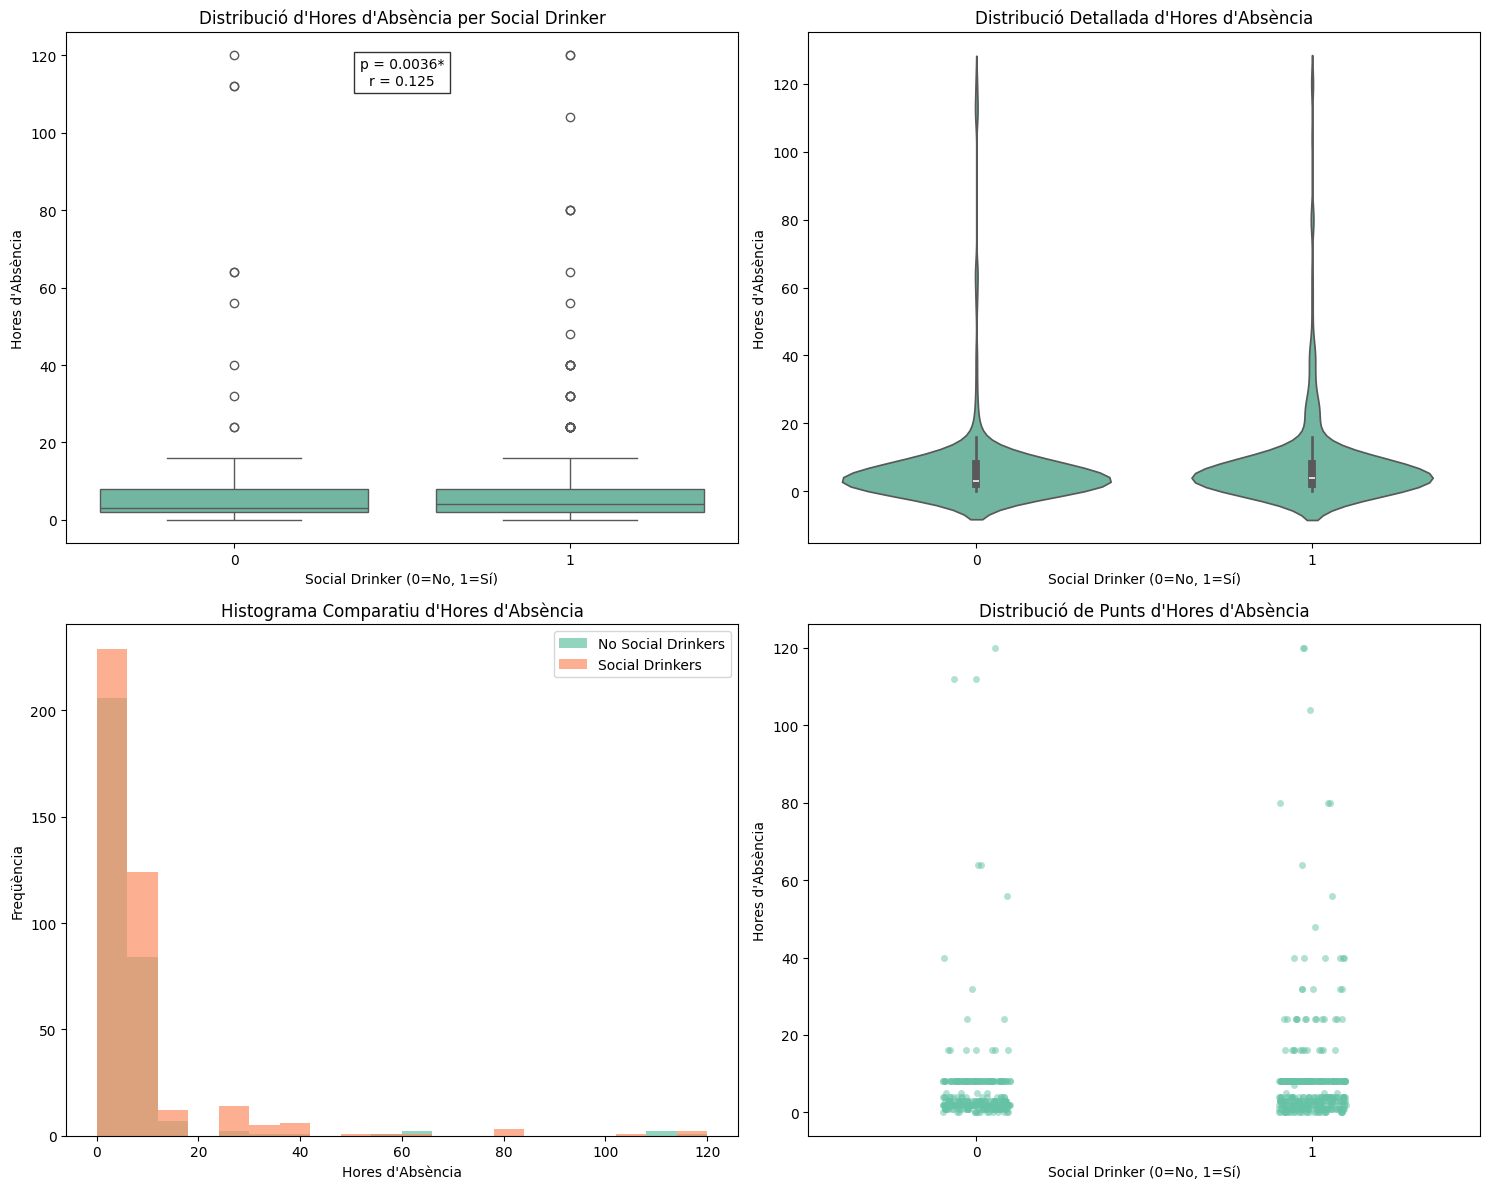


ANÀLISI ADDICIONAL: PROPORCIÓ DE CASOS AMB ABSÈNCIA ELEVADA
Llindar per a absència elevada: 8.00 hores
Proporció de no social drinkers amb absència elevada: 0.055
Proporció de social drinkers amb absència elevada: 0.115

Test Chi-quadrat per a absència elevada:
χ² = 6.944, p = 0.0084
Els social drinkers tenen significativament MÉS probabilitat d'absència elevada.

RECOMANACIONS BASADES EN ELS RESULTATS:
- Centrar les intervencions en els social drinkers, que mostren més absències.
- Considerar programes de suport per a la reducció del consum d'alcohol.

- La mida de l'efecte (0.125) indica un efecte petit.


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Configurar l'estil dels gràfics
plt.style.use('default')
sns.set_palette("Set2")

print("=== ANÀLISI MITJANÇANT MANN-WHITNEY U: SOCIAL DRINKER I ABSÈNCIA ===\n")

# Preparar les dades
group_0 = RRHH[RRHH['Social_drinker'] == 0]['Absenteeism_hours']
group_1 = RRHH[RRHH['Social_drinker'] == 1]['Absenteeism_hours']

# Estadístics descriptius
print("ESTADÍSTICS DESCRIPTIUS:")
print(f"No Social Drinkers (n={len(group_0)}):")
print(f"  Mitjana: {group_0.mean():.2f} hores")
print(f"  Mediana: {group_0.median():.2f} hores")
print(f"  Desviació estàndard: {group_0.std():.2f} hores")

print(f"\nSocial Drinkers (n={len(group_1)}):")
print(f"  Mitjana: {group_1.mean():.2f} hores")
print(f"  Mediana: {group_1.median():.2f} hores")
print(f"  Desviació estàndard: {group_1.std():.2f} hores")

# Test de Mann-Whitney U
print("\nTEST DE MANN-WHITNEY U:")
u_stat, p_value = stats.mannwhitneyu(group_0, group_1, alternative='two-sided')
print(f"Estadístic U: {u_stat}")
print(f"Valor p: {p_value:.4f}")

# Interpretació del valor p
if p_value < 0.05:
    print("HI HA una diferència estadísticament significativa entre els grups (p < 0.05)")
else:
    print("NO hi ha una diferència estadísticament significativa entre els grups (p ≥ 0.05)")

# Càlcul de la mida de l'efecte (r de Wilcoxon)
def wilcoxon_effect_size(u_stat, n1, n2):
    """Calcula la mida de l'efecte r per al test de Mann-Whitney U"""
    return 1 - (2 * u_stat) / (n1 * n2)

n1, n2 = len(group_0), len(group_1)
r_effect = wilcoxon_effect_size(u_stat, n1, n2)
print(f"\nMIDA DE L'EFECTE (r de Wilcoxon): {abs(r_effect):.3f}")

# Interpretació de la mida de l'efecte
if abs(r_effect) < 0.1:
    effect_size_str = "efecte negligible"
elif abs(r_effect) < 0.3:
    effect_size_str = "efecte petit"
elif abs(r_effect) < 0.5:
    effect_size_str = "efecte moderat"
else:
    effect_size_str = "efecte gran"

print(f"Interpretació: {effect_size_str}")

# Determinar què grup té més absències
median_0 = group_0.median()
median_1 = group_1.median()

if median_0 > median_1:
    print("\nEls NO social drinkers tenen MÉS hores d'absència (mediana més alta).")
elif median_1 > median_0:
    print("\nEls social drinkers tenen MÉS hores d'absència (mediana més alta).")
else:
    print("\nAmbdós grups tenen la mateixa mediana d'hores d'absència.")

# Visualització dels resultats
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Boxplot
sns.boxplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH, ax=axes[0, 0])
axes[0, 0].set_title('Distribució d\'Hores d\'Absència per Social Drinker')
axes[0, 0].set_xlabel('Social Drinker (0=No, 1=Sí)')
axes[0, 0].set_ylabel('Hores d\'Absència')

# Afegir annotations amb informació estadística
if p_value < 0.05:
    sig_text = f"p = {p_value:.4f}*\nr = {abs(r_effect):.3f}"
else:
    sig_text = f"p = {p_value:.4f}\nr = {abs(r_effect):.3f}"

axes[0, 0].text(0.5, 0.95, sig_text, transform=axes[0, 0].transAxes, 
                bbox=dict(facecolor='white', alpha=0.8), ha='center', va='top')

# Violin plot
sns.violinplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH, ax=axes[0, 1])
axes[0, 1].set_title('Distribució Detallada d\'Hores d\'Absència')
axes[0, 1].set_xlabel('Social Drinker (0=No, 1=Sí)')
axes[0, 1].set_ylabel('Hores d\'Absència')

# Histograma comparatiu
axes[1, 0].hist(group_0, alpha=0.7, label='No Social Drinkers', bins=20)
axes[1, 0].hist(group_1, alpha=0.7, label='Social Drinkers', bins=20)
axes[1, 0].set_title('Histograma Comparatiu d\'Hores d\'Absència')
axes[1, 0].set_xlabel('Hores d\'Absència')
axes[1, 0].set_ylabel('Freqüència')
axes[1, 0].legend()

# Gràfic de punts amb jitter
sns.stripplot(x='Social_drinker', y='Absenteeism_hours', data=RRHH, 
              ax=axes[1, 1], jitter=True, alpha=0.5)
axes[1, 1].set_title('Distribució de Punts d\'Hores d\'Absència')
axes[1, 1].set_xlabel('Social Drinker (0=No, 1=Sí)')
axes[1, 1].set_ylabel('Hores d\'Absència')

plt.tight_layout()
plt.show()

# Anàlisi addicional: Proporció de casos amb absència elevada
print("\nANÀLISI ADDICIONAL: PROPORCIÓ DE CASOS AMB ABSÈNCIA ELEVADA")

# Definir un llindar per a "absència elevada" (per exemple, percentil 75)
llindar_absencia = RRHH['Absenteeism_hours'].quantile(0.75)
print(f"Llindar per a absència elevada: {llindar_absencia:.2f} hores")

# Calcular proporcions per grup
prop_alta_0 = (group_0 > llindar_absencia).mean()
prop_alta_1 = (group_1 > llindar_absencia).mean()

print(f"Proporció de no social drinkers amb absència elevada: {prop_alta_0:.3f}")
print(f"Proporció de social drinkers amb absència elevada: {prop_alta_1:.3f}")

# Test Chi-quadrat per comparar proporcions
from scipy.stats import chi2_contingency

tabla_contingencia = pd.crosstab(RRHH['Social_drinker'], 
                                RRHH['Absenteeism_hours'] > llindar_absencia)
chi2, p_chi, dof, expected = chi2_contingency(tabla_contingencia)

print(f"\nTest Chi-quadrat per a absència elevada:")
print(f"χ² = {chi2:.3f}, p = {p_chi:.4f}")

if p_chi < 0.05:
    if prop_alta_0 > prop_alta_1:
        print("Els NO social drinkers tenen significativament MÉS probabilitat d'absència elevada.")
    else:
        print("Els social drinkers tenen significativament MÉS probabilitat d'absència elevada.")
else:
    print("NO hi ha diferència significativa en la probabilitat d'absència elevada entre grups.")

# Recomanacions basades en els resultats
print("\nRECOMANACIONS BASADES EN ELS RESULTATS:")

if p_value < 0.05:
    if median_0 > median_1:
        print("- Centrar les intervencions en els NO social drinkers, que mostren més absències.")
        print("- Investigar les causes d'absència en aquest grup (estrés, condicions de treball, etc.).")
    else:
        print("- Centrar les intervencions en els social drinkers, que mostren més absències.")
        print("- Considerar programes de suport per a la reducció del consum d'alcohol.")
else:
    print("- No hi ha evidència que el consum social d'alcohol estigui relacionat amb l'absentisme.")
    print("- Centrar els esforços en altres factors que puguin influir en l'absentisme.")

print(f"\n- La mida de l'efecte ({abs(r_effect):.3f}) indica un {effect_size_str}.")

=== ANÀLISI DE CORRELACIÓ: EDAT I ABSÈNCIES ===

1. ESTADÍSTICS DESCRIPTIUS:
Edat - Mitjana: 36.5 anys, Rang: 27-58
Absències - Mitjana: 7.1 hores, Rang: 0-120

2. VERIFICACIÓ DE SUPÒSITS:
Normalitat edat: p = 0.0000
Normalitat absències: p = 0.0000
Una o ambdues variables NO segueixen distribució normal → Spearman recomanat

3. ANÀLISI DE CORRELACIÓ:
Pearson: r = 0.066, p = 0.0805
Spearman: ρ = -0.065, p = 0.0831

4. INTERPRETACIÓ:
NO hi ha una correlació estadísticament significativa entre l'edat i les hores d'absència.

5. ANÀLISI PER GRUPS D'EDAT:
Mitjana d'hores d'absència per grup d'edat:
            mean    std  count
Grup_edat                     
<30         5.58  10.66    168
30-40       7.32  12.39    400
40-50       7.09  14.26    129
50+        29.11  49.40      9

ANOVA entre grups d'edat: F = 8.872, p = 0.0000

6. VISUALITZACIÓ DE LA RELACIÓ:


C:\Users\PC\AppData\Local\Temp\ipykernel_20872\175422284.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  absencia_per_edat = RRHH.groupby('Grup_edat')['Absenteeism_hours'].agg(['mean', 'std', 'count'])


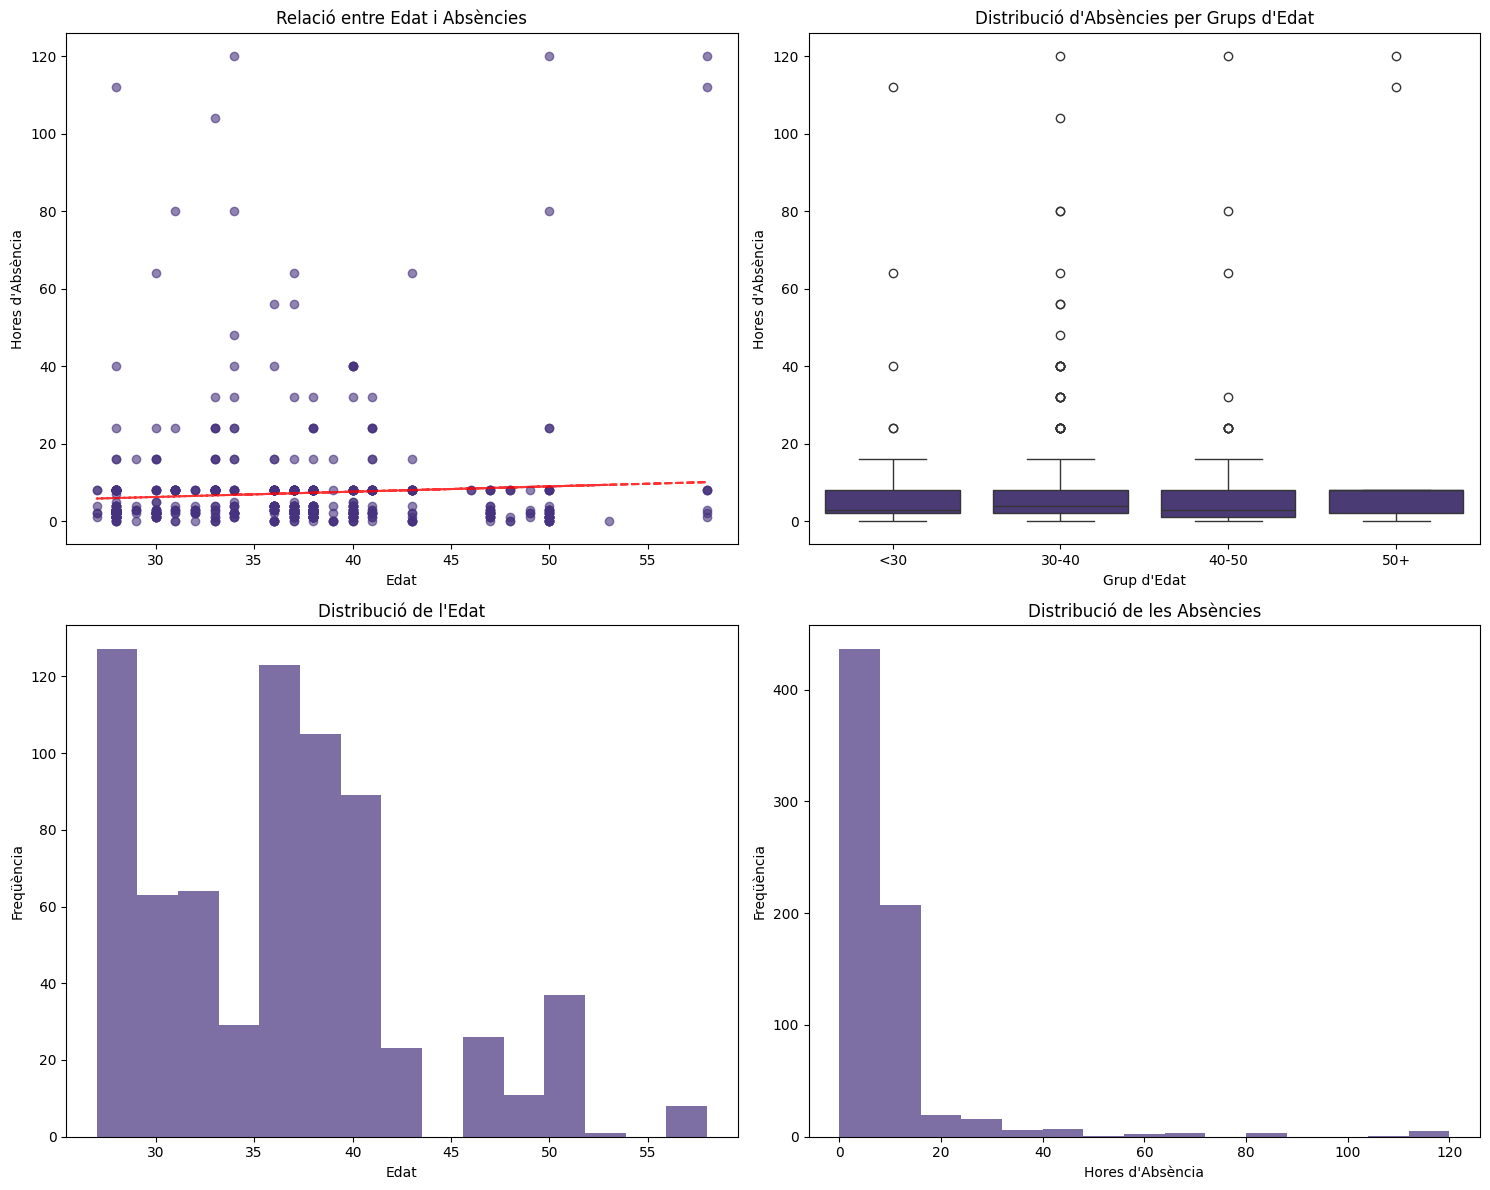


7. ANÀLISI DE VALORS EXTREMS:
Nombre de valors extrems en absències: 44
Mitjana d'edat dels valors extrems: 37.9 anys

8. RECOMANACIONS FINALS:
- L'edat no sembla ser un factor determinant en l'absentisme.
- Centrar els esforços en altres factors com motius d'absència o condicions de treball.

Mètode estadístic recomanat: Correlació de Spearman


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Configurar l'estil
plt.style.use('default')
sns.set_palette("viridis")

print("=== ANÀLISI DE CORRELACIÓ: EDAT I ABSÈNCIES ===\n")

# 1. Anàlisi exploratòria inicial
print("1. ESTADÍSTICS DESCRIPTIUS:")
print(f"Edat - Mitjana: {RRHH['Age'].mean():.1f} anys, Rang: {RRHH['Age'].min()}-{RRHH['Age'].max()}")
print(f"Absències - Mitjana: {RRHH['Absenteeism_hours'].mean():.1f} hores, Rang: {RRHH['Absenteeism_hours'].min()}-{RRHH['Absenteeism_hours'].max()}")

# 2. Verificació de supòsits
print("\n2. VERIFICACIÓ DE SUPÒSITS:")

# Normalitat (Shapiro-Wilk)
_, p_age = stats.shapiro(RRHH['Age'])
_, p_abs = stats.shapiro(RRHH['Absenteeism_hours'])
print(f"Normalitat edat: p = {p_age:.4f}")
print(f"Normalitat absències: p = {p_abs:.4f}")

# Decidir quin test de correlació utilitzar
if p_age > 0.05 and p_abs > 0.05:
    print("Ambdues variables segueixen una distribució normal → Pearson adequat")
    test_principal = "Pearson"
else:
    print("Una o ambdues variables NO segueixen distribució normal → Spearman recomanat")
    test_principal = "Spearman"

# 3. Anàlisi de correlació principal
print("\n3. ANÀLISI DE CORRELACIÓ:")

# Correlació de Pearson
corr_pearson, p_pearson = stats.pearsonr(RRHH['Age'], RRHH['Absenteeism_hours'])
print(f"Pearson: r = {corr_pearson:.3f}, p = {p_pearson:.4f}")

# Correlació de Spearman
corr_spearman, p_spearman = stats.spearmanr(RRHH['Age'], RRHH['Absenteeism_hours'])
print(f"Spearman: ρ = {corr_spearman:.3f}, p = {p_spearman:.4f}")

# 4. Interpretació dels resultats
print("\n4. INTERPRETACIÓ:")

# Utilitzar el test principal per la interpretació
if test_principal == "Pearson":
    corr_value = corr_pearson
    p_value = p_pearson
else:
    corr_value = corr_spearman
    p_value = p_spearman

if p_value < 0.05:
    if corr_value > 0:
        print("Hi ha una correlació POSITIVA estadísticament significativa.")
        print("Les persones més grans tendeixen a tenir MÉS hores d'absència.")
    else:
        print("Hi ha una correlació NEGATIVA estadísticament significativa.")
        print("Les persones més grans tendeixen a tenir MENYS hores d'absència.")
    
    # Interpretar la força de la correlació
    if abs(corr_value) < 0.3:
        fuerza = "feble"
    elif abs(corr_value) < 0.5:
        fuerza = "moderada"
    elif abs(corr_value) < 0.7:
        fuerza = "forta"
    else:
        fuerza = "molt forta"
    
    print(f"La correlació és de {fuerza} magnitud (|r| = {abs(corr_value):.3f}).")
else:
    print("NO hi ha una correlació estadísticament significativa entre l'edat i les hores d'absència.")

# 5. Anàlisi addicional per grups d'edat
print("\n5. ANÀLISI PER GRUPS D'EDAT:")

# Crear grups d'edat
RRHH['Grup_edat'] = pd.cut(RRHH['Age'], 
                          bins=[0, 30, 40, 50, 100], 
                          labels=['<30', '30-40', '40-50', '50+'])

# Estadístics per grup d'edat
absencia_per_edat = RRHH.groupby('Grup_edat')['Absenteeism_hours'].agg(['mean', 'std', 'count'])
print("Mitjana d'hores d'absència per grup d'edat:")
print(absencia_per_edat.round(2))

# Test ANOVA per comparar mitjanes entre grups
grupos = [RRHH[RRHH['Grup_edat'] == grupo]['Absenteeism_hours'] for grupo in RRHH['Grup_edat'].unique()]
f_stat, p_anova = stats.f_oneway(*grupos)
print(f"\nANOVA entre grups d'edat: F = {f_stat:.3f}, p = {p_anova:.4f}")

# 6. Visualitzacions
print("\n6. VISUALITZACIÓ DE LA RELACIÓ:")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot
axes[0, 0].scatter(RRHH['Age'], RRHH['Absenteeism_hours'], alpha=0.6)
axes[0, 0].set_xlabel('Edat')
axes[0, 0].set_ylabel('Hores d\'Absència')
axes[0, 0].set_title('Relació entre Edat i Absències')
# Línia de tendència
z = np.polyfit(RRHH['Age'], RRHH['Absenteeism_hours'], 1)
p = np.poly1d(z)
axes[0, 0].plot(RRHH['Age'], p(RRHH['Age']), "r--", alpha=0.8)

# Boxplot per grups d'edat
sns.boxplot(x='Grup_edat', y='Absenteeism_hours', data=RRHH, ax=axes[0, 1])
axes[0, 1].set_title('Distribució d\'Absències per Grups d\'Edat')
axes[0, 1].set_xlabel('Grup d\'Edat')
axes[0, 1].set_ylabel('Hores d\'Absència')

# Histograma d'edat
axes[1, 0].hist(RRHH['Age'], bins=15, alpha=0.7)
axes[1, 0].set_title('Distribució de l\'Edat')
axes[1, 0].set_xlabel('Edat')
axes[1, 0].set_ylabel('Freqüència')

# Histograma d'absències
axes[1, 1].hist(RRHH['Absenteeism_hours'], bins=15, alpha=0.7)
axes[1, 1].set_title('Distribució de les Absències')
axes[1, 1].set_xlabel('Hores d\'Absència')
axes[1, 1].set_ylabel('Freqüència')

plt.tight_layout()
plt.show()

# 7. Anàlisi de valors extrems
print("\n7. ANÀLISI DE VALORS EXTREMS:")

# Identificar valors extrems en absències
Q1 = RRHH['Absenteeism_hours'].quantile(0.25)
Q3 = RRHH['Absenteeism_hours'].quantile(0.75)
IQR = Q3 - Q1
lim_superior = Q3 + 1.5 * IQR

valors_extrems = RRHH[RRHH['Absenteeism_hours'] > lim_superior]
print(f"Nombre de valors extrems en absències: {len(valors_extrems)}")
print(f"Mitjana d'edat dels valors extrems: {valors_extrems['Age'].mean():.1f} anys")

# 8. Recomanacions finals
print("\n8. RECOMANACIONS FINALS:")

if p_value < 0.05:
    if corr_value > 0:
        print("- Les persones majors requereixen més atenció en programes de benestar.")
        print("- Implementar programes de salut ocupacional adaptats a treballadors majors.")
    else:
        print("- Les persones joves podrien necessitar més suport i formació.")
        print("- Desenvolupar programes de prevenció d'accidents per a treballadors joves.")
else:
    print("- L'edat no sembla ser un factor determinant en l'absentisme.")
    print("- Centrar els esforços en altres factors com motius d'absència o condicions de treball.")

print(f"\nMètode estadístic recomanat: Correlació de {test_principal}")

In [31]:
# Correlació de Spearman (relació monòtona)
corr_spearman, p_spearman = stats.spearmanr(RRHH['Age'], RRHH['Absenteeism_hours'])
print(f"Correlació de Spearman: ρ = {corr_spearman:.3f}, p = {p_spearman:.4f}")

Correlació de Spearman: ρ = -0.065, p = 0.0831


=== ANÀLISI DE CORRELACIÓ SPEARMAN: EDAT I ABSÈNCIES ===

1. PREPARACIÓ DE DADES:
Nombre total de registres: 706
Registres vàlids per a l'anàlisi: 706

2. ESTADÍSTICS DESCRIPTIUS:
Edat - Mitjana: 36.5 anys
Edat - Desviació estàndard: 6.6 anys
Edat - Rang: 27-58 anys
Absències - Mitjana: 7.1 hores
Absències - Desviació estàndard: 13.6 hores
Absències - Rang: 0-120 hores

3. CORRELACIÓ DE SPEARMAN:
Coeficient de correlació de Spearman (ρ): -0.065
Valor p: 0.0831

4. INTERPRETACIÓ:
NO hi ha una correlació estadísticament significativa entre l'edat i les hores d'absència.
La magnitud de la correlació és negligible (|ρ| = 0.065).

5. VISUALITZACIÓ:


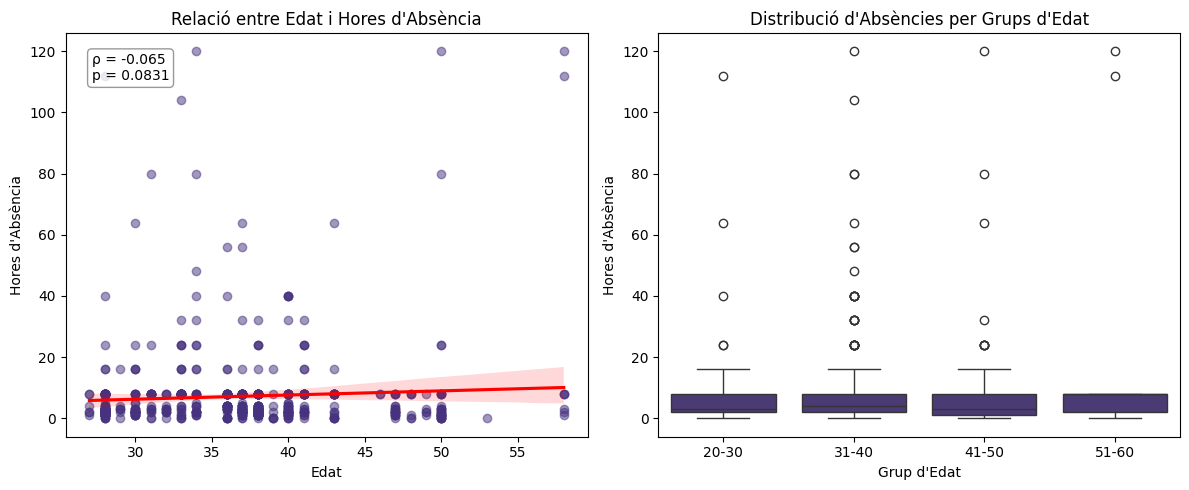


6. ANÀLISI PER QUARTILS D'EDAT:
Quartils d'edat: Q1=31.0, Q2=37.0, Q3=40.0

Mitjana d'hores d'absència per quartil d'edat:
              mean    std  count
Quartil_edat                    
Q1            6.07  11.50    190
Q2            8.62  14.53    216
Q3            5.25   7.49    162
Q4            8.52  19.03    138

Test de Kruskal-Wallis: H = 22.204, p = 0.0001
HI HA diferències significatives en l'absentisme entre els quartils d'edat.

7. RECOMANACIONS:
- L'edat no sembla ser un factor determinant en l'absentisme.
- Centrar els esforços en altres factors com motius d'absència o condicions de treball.

- La correlació és de magnitud negligible, el que indica que l'edat explica aproximadament 0.4% de la variància en l'absentisme.

8. LIMITACIONS:
- La correlació no implica causalitat: una relació estadística no prova que l'edat causi absències.
- Hi poden haver variables de confusió (com antiguitat, tipus de feina, etc.) que influeixin en la relació.
- Es recomana complementar amb

C:\Users\PC\AppData\Local\Temp\ipykernel_20872\1979160491.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  absencia_per_quartil = data.groupby('Quartil_edat')['Absenteeism_hours'].agg(['mean', 'std', 'count'])


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Configurar l'estil
plt.style.use('default')
sns.set_palette("viridis")

print("=== ANÀLISI DE CORRELACIÓ SPEARMAN: EDAT I ABSÈNCIES ===\n")

# 1. Neteja i preparació de dades
print("1. PREPARACIÓ DE DADES:")
print(f"Nombre total de registres: {len(RRHH)}")

# Eliminar files amb valors null en les variables d'interès
data = RRHH[['Age', 'Absenteeism_hours']].dropna()
print(f"Registres vàlids per a l'anàlisi: {len(data)}")

# 2. Estadístics descriptius
print("\n2. ESTADÍSTICS DESCRIPTIUS:")
print(f"Edat - Mitjana: {data['Age'].mean():.1f} anys")
print(f"Edat - Desviació estàndard: {data['Age'].std():.1f} anys")
print(f"Edat - Rang: {data['Age'].min()}-{data['Age'].max()} anys")
print(f"Absències - Mitjana: {data['Absenteeism_hours'].mean():.1f} hores")
print(f"Absències - Desviació estàndard: {data['Absenteeism_hours'].std():.1f} hores")
print(f"Absències - Rang: {data['Absenteeism_hours'].min()}-{data['Absenteeism_hours'].max()} hores")

# 3. Anàlisi de correlació de Spearman
print("\n3. CORRELACIÓ DE SPEARMAN:")
corr_spearman, p_value = stats.spearmanr(data['Age'], data['Absenteeism_hours'])
print(f"Coeficient de correlació de Spearman (ρ): {corr_spearman:.3f}")
print(f"Valor p: {p_value:.4f}")

# 4. Interpretació dels resultats
print("\n4. INTERPRETACIÓ:")

if p_value < 0.05:
    if corr_spearman > 0:
        print("HI HA una correlació POSITIVA estadísticament significativa.")
        print("Les persones més grans tendeixen a tenir MÉS hores d'absència.")
    else:
        print("HI HA una correlació NEGATIVA estadísticament significativa.")
        print("Les persones més grans tendeixen a tenir MENYS hores d'absència.")
else:
    print("NO hi ha una correlació estadísticament significativa entre l'edat i les hores d'absència.")

# Interpretar la força de la correlació
if abs(corr_spearman) < 0.1:
    fuerza = "negligible"
elif abs(corr_spearman) < 0.3:
    fuerza = "feble"
elif abs(corr_spearman) < 0.5:
    fuerza = "moderada"
elif abs(corr_spearman) < 0.7:
    fuerza = "forta"
else:
    fuerza = "molt forta"

print(f"La magnitud de la correlació és {fuerza} (|ρ| = {abs(corr_spearman):.3f}).")

# 5. Visualització de la relació
print("\n5. VISUALITZACIÓ:")

plt.figure(figsize=(12, 5))

# Gràfic de dispersió (scatter plot) amb línia de tendència
plt.subplot(1, 2, 1)
sns.regplot(x='Age', y='Absenteeism_hours', data=data, 
           scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relació entre Edat i Hores d\'Absència')
plt.xlabel('Edat')
plt.ylabel('Hores d\'Absència')

# Afegir annotació amb el coeficient de correlació
plt.annotate(f'ρ = {corr_spearman:.3f}\np = {p_value:.4f}', 
             xy=(0.05, 0.95), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
             fontsize=10, verticalalignment='top')

# Boxplot per mostrar la distribució d'absències per grups d'edat
plt.subplot(1, 2, 2)
data['Grup_edat'] = pd.cut(data['Age'], bins=[20, 30, 40, 50, 60], 
                          labels=['20-30', '31-40', '41-50', '51-60'])
sns.boxplot(x='Grup_edat', y='Absenteeism_hours', data=data)
plt.title('Distribució d\'Absències per Grups d\'Edat')
plt.xlabel('Grup d\'Edat')
plt.ylabel('Hores d\'Absència')

plt.tight_layout()
plt.show()

# 6. Anàlisi addicional: Correlació per quartils d'edat
print("\n6. ANÀLISI PER QUARTILS D'EDAT:")

# Calcular quartils d'edat
quartils = data['Age'].quantile([0.25, 0.5, 0.75])
print(f"Quartils d'edat: Q1={quartils[0.25]:.1f}, Q2={quartils[0.5]:.1f}, Q3={quartils[0.75]:.1f}")

# Crear grups segons quartils
data['Quartil_edat'] = pd.qcut(data['Age'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Calcular mitjanes d'absències per quartil
absencia_per_quartil = data.groupby('Quartil_edat')['Absenteeism_hours'].agg(['mean', 'std', 'count'])
print("\nMitjana d'hores d'absència per quartil d'edat:")
print(absencia_per_quartil.round(2))

# Test de Kruskal-Wallis (ANOVA no paramètric) per comparar els quartils
grupos = [data[data['Quartil_edat'] == q]['Absenteeism_hours'] for q in ['Q1', 'Q2', 'Q3', 'Q4']]
h_stat, p_kruskal = stats.kruskal(*grupos)
print(f"\nTest de Kruskal-Wallis: H = {h_stat:.3f}, p = {p_kruskal:.4f}")

if p_kruskal < 0.05:
    print("HI HA diferències significatives en l'absentisme entre els quartils d'edat.")
else:
    print("NO hi ha diferències significatives en l'absentisme entre els quartils d'edat.")

# 7. Recomanacions basades en els resultats
print("\n7. RECOMANACIONS:")

if p_value < 0.05:
    if corr_spearman > 0:
        print("- Implementar programes de salut i benestar dirigits als treballadors més grans.")
        print("- Considerar adaptacions ergonòmiques per als treballadors d'edat avançada.")
        print("- Revisar les polítiques de prevenció d'absències per a treballadors veterans.")
    else:
        print("- Desenvolupar programes de prevenció d'accidents per a treballadors joves.")
        print("- Millorar la formació i integració dels treballadors més joves.")
        print("- Revisar les condicions de treball per als treballadors novells.")
else:
    print("- L'edat no sembla ser un factor determinant en l'absentisme.")
    print("- Centrar els esforços en altres factors com motius d'absència o condicions de treball.")

print(f"\n- La correlació és de magnitud {fuerza}, el que indica que l'edat explica aproximadament {(corr_spearman**2)*100:.1f}% de la variància en l'absentisme.")

# 8. Limitacions de l'anàlisi
print("\n8. LIMITACIONS:")
print("- La correlació no implica causalitat: una relació estadística no prova que l'edat causi absències.")
print("- Hi poden haver variables de confusió (com antiguitat, tipus de feina, etc.) que influeixin en la relació.")
print("- Es recomana complementar amb anàlisis multivariants que controlin per altres variables.")